<a href="https://colab.research.google.com/github/Swaroop8763/insurance-premium-prediction/blob/main/insurance_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q ipywidgets
import ipywidgets as widgets
widgets.Widget.close_all()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.4 MB/s eta 0:00:00


In [2]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as spy
from scipy.stats import chi2_contingency
from scipy.stats import shapiro
from scipy.stats import boxcox,uniform,randint
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import optuna
import pickle

In [4]:
import importlib.metadata

def get_library_version(library_name):
    try:
        return importlib.metadata.version(library_name)
    except importlib.metadata.PackageNotFoundError:
        return "Not Found"

libraries = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scipy',
    'scikit-learn',
    'statsmodels',
    'mlxtend',
    'xgboost',
    'lightgbm',
    'optuna',
    'streamlit'
]

print("Library Versions:")
for lib in libraries:
    print(f"{lib}: {get_library_version(lib)}")

Library Versions:
pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.16.3
scikit-learn: 1.6.1
statsmodels: 0.14.6
mlxtend: 0.23.4
xgboost: 3.2.0
lightgbm: 4.6.0
optuna: 4.9.0
streamlit: Not Found


In [5]:
Path = "/content/drive/MyDrive/dataset/insurance (1).csv"
data = pd.read_csv(Path)
data.sample(5)

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
536,65,0,1,0,0,177,79,0,0,2,28000
939,43,0,0,0,0,159,72,0,0,1,23000
102,59,1,1,0,0,160,92,0,1,1,31000
588,42,0,0,0,1,185,90,0,0,0,30000
874,51,1,1,0,0,152,72,0,0,1,29000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


#Changing Datatype

In [7]:
data["HistoryOfCancerInFamily"] = data["HistoryOfCancerInFamily"].astype("object")
data["Diabetes"] = data["Diabetes"].astype("object")
data["BloodPressureProblems"] = data["BloodPressureProblems"].astype("object")
data["AnyTransplants"] = data["AnyTransplants"].astype("object")
data["AnyChronicDiseases"] = data["AnyChronicDiseases"].astype("object")
data["KnownAllergies"] = data["KnownAllergies"].astype("object")

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      986 non-null    int64 
 1   Diabetes                 986 non-null    object
 2   BloodPressureProblems    986 non-null    object
 3   AnyTransplants           986 non-null    object
 4   AnyChronicDiseases       986 non-null    object
 5   Height                   986 non-null    int64 
 6   Weight                   986 non-null    int64 
 7   KnownAllergies           986 non-null    object
 8   HistoryOfCancerInFamily  986 non-null    object
 9   NumberOfMajorSurgeries   986 non-null    int64 
 10  PremiumPrice             986 non-null    int64 
dtypes: int64(5), object(6)
memory usage: 84.9+ KB


**count of unique variable**

In [9]:
data.nunique()

,0
Age,49
Diabetes,2
BloodPressureProblems,2
AnyTransplants,2
AnyChronicDiseases,2
Height,44
Weight,74
KnownAllergies,2
HistoryOfCancerInFamily,2
NumberOfMajorSurgeries,4


#Checking null values & Duplicate values


In [10]:
data.isnull().sum()

,0
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


There is no Null values in any of the columns

**Checking the Duplicated values**

In [11]:
data.duplicated().sum()

np.int64(0)

There is no Duplicated values are present in the given dataset

**Describing the data**

In [12]:
data.describe(include = "all").T.round(2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,986.0,NaN,NaN,NaN,41.75,13.96,18.0,30.0,42.0,53.0,66.0
Diabetes,986.0,2.0,0.0,572.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BloodPressureProblems,986.0,2.0,0.0,524.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnyTransplants,986.0,2.0,0.0,931.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnyChronicDiseases,986.0,2.0,0.0,808.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height,986.0,NaN,NaN,NaN,168.18,10.10,145.0,161.0,168.0,176.0,188.0
Weight,986.0,NaN,NaN,NaN,76.95,14.27,51.0,67.0,75.0,87.0,132.0
KnownAllergies,986.0,2.0,0.0,774.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HistoryOfCancerInFamily,986.0,2.0,0.0,870.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfMajorSurgeries,986.0,NaN,NaN,NaN,0.67,0.75,0.0,0.0,1.0,1.0,3.0


Over here we are describing the data . where the count of the data 986 in all the columns given in the given dataset.

**Age**- Where the minimum age is 18 , maximum age is 66 and average age is 41.

**Diabetes**- over here the columns boolean which represent in "0","1".

**BP**- over here the columns boolean which represent in "0","1".

**AnyTransplants**- over here the columns boolean which represent in "0","1".

**AnyChronicDiseases**- over here the columns boolean which represent in "0","1".

**Height**- over here the height are mentioned in Centimeters.

**Weight**- over here weight is given in Kilograms.

**Known Allergies** - over here the columns boolean which represent in "0","1".

**History Of Cancer in Family**- over here the columns boolean which represent in "0","1".

**Number Of Major Surgeries**- over here the columns boolean which represent in "0","1".

**Premium Price**- Over her price is given in rupees.

In [13]:
data.columns

Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice'],
      dtype='object')

**Creating two variables**

In [14]:
def get_columns_types(data):
  cat_col=[]
  num_col=[]
  for col in data.columns:
    if data[col].dtype == "object":
      cat_col.append(col)
    else:
      num_col.append(col)
  return cat_col,num_col

In [15]:
cat_col,num_col = get_columns_types(data)

In [16]:
cat_col= data[cat_col]
num_col= data[num_col]

In [17]:
cat_col.sample(2)

,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,KnownAllergies,HistoryOfCancerInFamily
350,1,0,0,0,0,0
375,1,0,0,0,0,0


In [18]:
num_col.sample(2)

,Age,Height,Weight,NumberOfMajorSurgeries,PremiumPrice
498,62,167,67,2,28000
642,44,184,65,1,23000


In [19]:
num_col.corr()

,Age,Height,Weight,NumberOfMajorSurgeries,PremiumPrice
Age,1.000000,0.039879,-0.018590,0.429181,0.697540
Height,0.039879,1.000000,0.066946,0.037289,0.026910
Weight,-0.018590,0.066946,1.000000,-0.006108,0.141507
NumberOfMajorSurgeries,0.429181,0.037289,-0.006108,1.000000,0.264250
PremiumPrice,0.697540,0.026910,0.141507,0.264250,1.000000


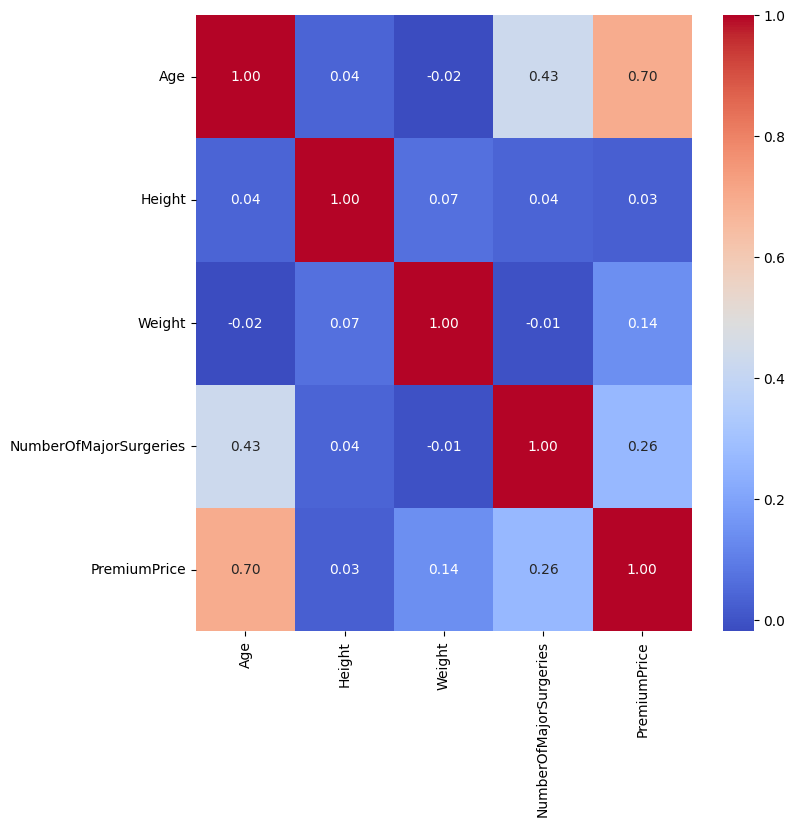

In [20]:
plt.figure(figsize=(8,8))
sns.heatmap(num_col.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

There is strong corelation

**Outlier Detection :**

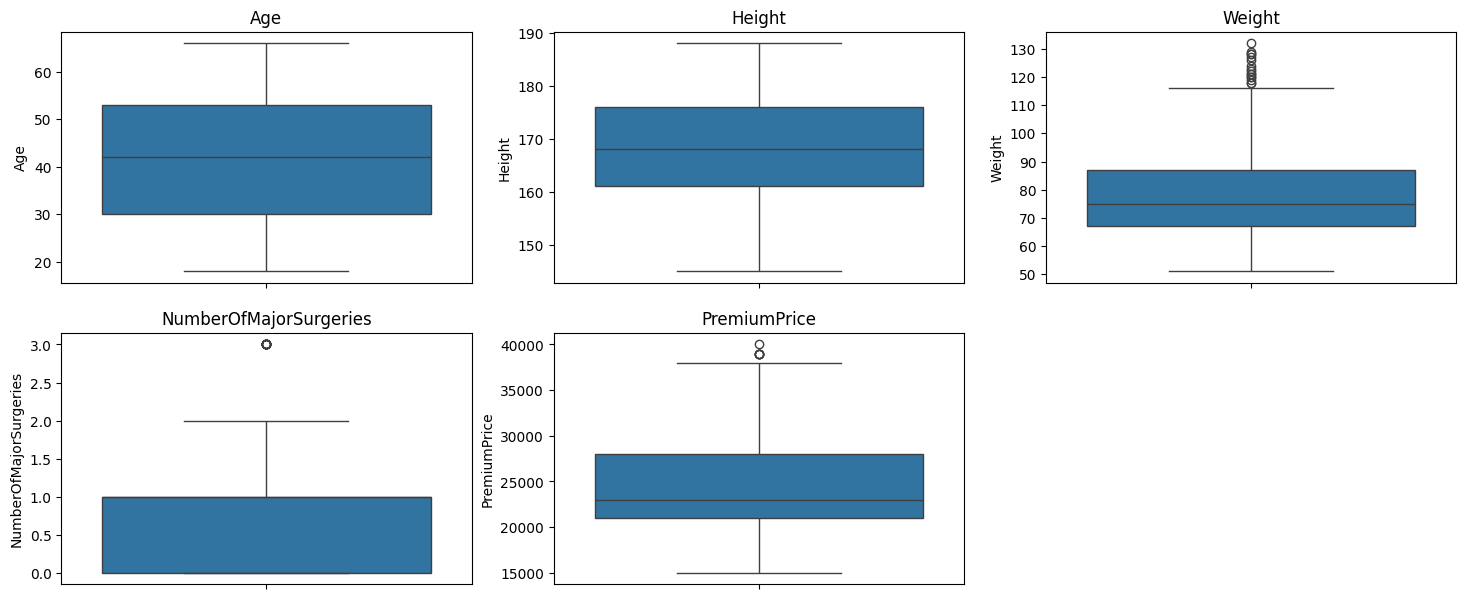

In [21]:
plt.figure(figsize=(18,15))
for i in range(num_col.shape[1]):
    plt.subplot(4,3,i+1)
    sns.boxplot(num_col[num_col.columns[i]])
    plt.title(num_col.columns[i])
plt.tight_layout
plt.show()

In [22]:
print(f'premium price :{data["PremiumPrice"].skew()}')
print(f'Weight:{data["Weight"].skew()}')
print(f'Number Of Major Surgeries : {data["NumberOfMajorSurgeries"].skew()}')

premium price :0.09763944413484053
Weight:0.666726314567332
Number Of Major Surgeries : 0.8613335798056603


In [23]:
pc_Weight_25 = np.quantile(data["Weight"],0.25)
pc_Weight_75 = np.quantile(data["Weight"],0.75)
iqr_pc_Weight = pc_Weight_75 - pc_Weight_25
lower_bound_pc_Weight = pc_Weight_25 - (1.5*iqr_pc_Weight)
upper_bound_pc_Weight = pc_Weight_75 + (1.5*iqr_pc_Weight)
outlier_Weight = data[(data["Weight"]>upper_bound_pc_Weight) | (data["Weight"]<lower_bound_pc_Weight)]
outlier_Weight.shape[0]
print(f'Number of outlier of Weight: {outlier_Weight.shape[0]}')

Number of outlier of Weight: 16


In [24]:
pc_NumberOfMajorSurgeries_25 = np.quantile(data["NumberOfMajorSurgeries"],0.25)
pc_NumberOfMajorSurgeries_75 = np.quantile(data["NumberOfMajorSurgeries"],0.75)
iqr_pc_NumberOfMajorSurgeries = pc_NumberOfMajorSurgeries_75 - pc_NumberOfMajorSurgeries_25
lower_bound_pc_NumberOfMajorSurgeries = pc_NumberOfMajorSurgeries_25 - (1.5*iqr_pc_NumberOfMajorSurgeries)
upper_bound_pc_NumberOfMajorSurgeries = pc_NumberOfMajorSurgeries_75 + (1.5*iqr_pc_NumberOfMajorSurgeries)
outlier_NumberOfMajorSurgeries = data[(data["NumberOfMajorSurgeries"]>upper_bound_pc_NumberOfMajorSurgeries) | (data["NumberOfMajorSurgeries"]<lower_bound_pc_NumberOfMajorSurgeries)]
print(f'Number of outlier of Surgeries :{outlier_NumberOfMajorSurgeries.shape[0]}')

Number of outlier of Surgeries :16


In [25]:
pc_premiumprice_25= np.quantile(data["PremiumPrice"],0.25)
pc_premiumprice_75= np.quantile(data["PremiumPrice"],0.75)
iqr_pc_premiumprice = pc_premiumprice_75 - pc_premiumprice_25
lower_bound_pc_premiumprice = pc_premiumprice_25 - (1.5*iqr_pc_premiumprice)
upper_bound_pc_premiumprice = pc_premiumprice_75 + (1.5*iqr_pc_premiumprice)
outlier_premiumprice = data[(data["PremiumPrice"]>upper_bound_pc_premiumprice) | (data["PremiumPrice"]<lower_bound_pc_premiumprice)]
print(f'Number of outlier of Price: {outlier_premiumprice.shape[0]}')

Number of outlier of Price: 6


**Droping The Outlier**

In [26]:
data_cleaned_outlier = data.copy()

In [27]:
len(data_cleaned_outlier)

986

In [28]:
outlier_indices = outlier_premiumprice.index.union(outlier_NumberOfMajorSurgeries.index).union(outlier_Weight.index)
data_cleaned_outlier = data_cleaned_outlier.drop(outlier_indices)
len(data_cleaned_outlier)

949

In [29]:
data_cleaned_outlier=data_cleaned_outlier.reset_index(drop= True)

**Checking the Null Values**

In [30]:
data_cleaned_outlier.isna().sum()

,0
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


#**Hypothesis Testing**

**General Structure of hypothesis testing**

---



*   Null_Hypothesis(H_O): State there is no effect,no difference, or no Relationship.
*   Alternative_Hypothesis(H_1): state there is an effect, a difference, or a Relationship
*   Significance_level:(0.05)or(5%)

***Assumptions For Performing the T-Test***

*   Normality - The data shoul be approximately normally distributed.
*   Independence - The observatin within each group should be independent of each other.

*   Homogeneity of variance - for independent sample t-test, the variance of the two group being compare should be roughly equal.


*   continuos Data - the dependent variable should be measured on a continuos scale(interval or ratio).

# **Diabetes**


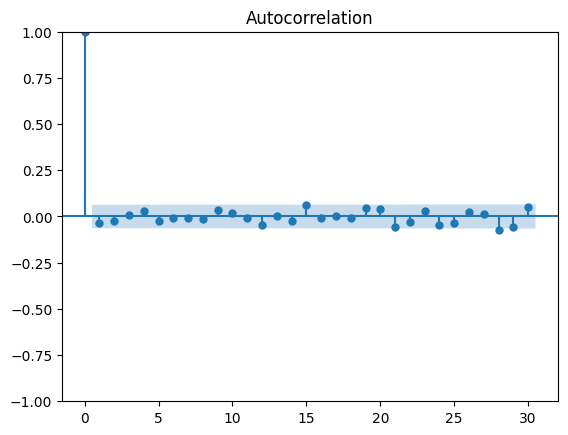

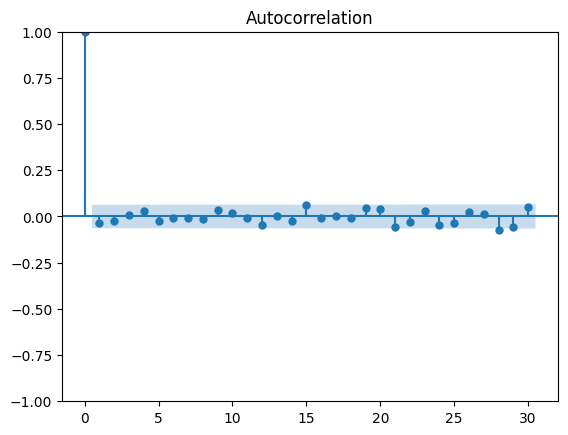

In [31]:
# Checking autocorrelation for Blood Pressure
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data_cleaned_outlier["Diabetes"])

**The autocorrelation check shows that your data does not violate the assumption of independence.**

In [32]:
group0_diabetes = data_cleaned_outlier[data_cleaned_outlier["Diabetes"]==0]["PremiumPrice"]
group1_diabetes = data_cleaned_outlier[data_cleaned_outlier["Diabetes"]==1]["PremiumPrice"]

In [33]:
# Normality test on group 0
from scipy.stats import shapiro

stat,p_value = shapiro(group0_diabetes)
print(f'shapiro_wilk stat:{stat},p_value:{p_value}')

alpha = 0.05
if p_value < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
  print("perform non-parametric test")
else:
  print("fail to reject the null hypothesis, the data is normally distributed")

shapiro_wilk stat:0.919931588502668,p_value:1.405381173683715e-16
reject the null hypothesis, the data is not normally distributed
perform non-parametric test


In [34]:
# Normality test on group 1
from scipy.stats import shapiro

stat,p_value_shapiro_group1 = shapiro(group1_diabetes)
print(f'shapiro_wilk stat:{stat},p_value:{p_value_shapiro_group1}')

alpha = 0.05
if p_value_shapiro_group1 < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
  print("perform non-parametric test")
else:
  print("fail to reject the null hypothesis, the data is normally distributed")

shapiro_wilk stat:0.9229274998556761,p_value:2.386614546996596e-13
reject the null hypothesis, the data is not normally distributed
perform non-parametric test


In [35]:
# non parametric test
from scipy.stats import mannwhitneyu
stat,p_value = mannwhitneyu(group0_diabetes,group1_diabetes)
print(f'stat:{stat},p_value:{p_value}')

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference in the distributions of PremiumPrice between the two groups.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in the distributions of PremiumPrice between the two groups.")

stat:99380.0,p_value:0.015123450273138734
Reject the null hypothesis: There is a significant difference in the distributions of PremiumPrice between the two groups.


# **Blood Pressure**

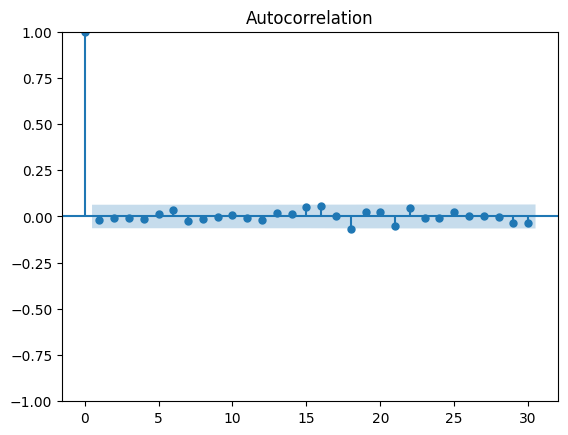

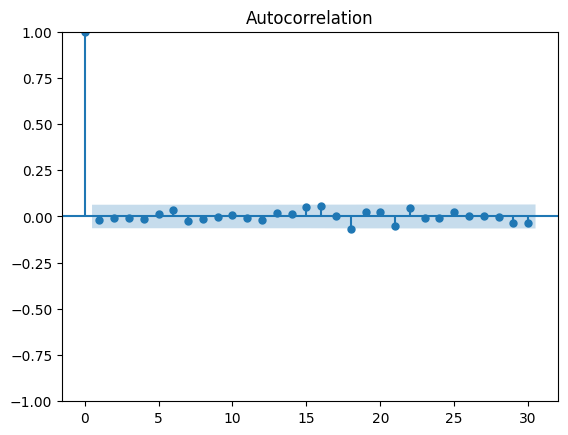

In [36]:
# Checking autocorrelation for Blood Pressure
plot_acf(data_cleaned_outlier["BloodPressureProblems"])


**The autocorrelation check shows that your data does not violate the assumption of independence.**

In [37]:
group0_bp = data_cleaned_outlier[data_cleaned_outlier["BloodPressureProblems"]==0]["PremiumPrice"]
group1_bp = data_cleaned_outlier[data_cleaned_outlier["BloodPressureProblems"]==1]["PremiumPrice"]

In [38]:
# Normality test on bp
# null hypothesis = the data follow normal distribution
# alternate hypothesis = the data dosent follow the distribution

stats_bp_0,p_value_bp_0 = shapiro(group0_bp)
print(f'statistic:{stats_bp_0},p_value:{p_value_bp_0}')

alpha = 0.05
if p_value_bp_0 < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
else:
  print("fail to reject the null hypothesis, the data is normally distributed")

statistic:0.9026704372912387,p_value:2.2074245071893782e-17
reject the null hypothesis, the data is not normally distributed


In [39]:
# Normality test on bp
# null hypothesis = the data follow normal distribution
# alternate hypothesis = the data dosent follow the distribution

stats_bp_1,p_value_bp_1 = shapiro(group1_bp)
print(f'statistic:{stats_bp_1},p_value:{p_value_bp_1}')

alpha = 0.05
if p_value_bp_1 < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
else:
  print("fail to reject the null hypothesis, the data is normally distributed")

statistic:0.9320468732905461,p_value:2.2820865586222827e-13
reject the null hypothesis, the data is not normally distributed


In [40]:
# performing the non - parametric test
# null- hypothesis = There is significant no difference between the two groups
# alternate hypothesis = there is significanr difference between the two groups
stats_bp_non,p_value_bp_non = mannwhitneyu(group0_bp,group1_bp)
print(f'stats:{stats_bp_non},p_value:{p_value_bp_non}')

alpha = 0.05

if p_value_bp_non < alpha:
  print("reject the null hypothesis,there is significant difference between the two groups")
else:
  print(print("fail to reject the null hypothesis,there is no significant difference between the two groups"))

stats:89642.0,p_value:5.7075712018912745e-08
reject the null hypothesis,there is significant difference between the two groups


**Any Transplant**

In [41]:
group0_at = data_cleaned_outlier[data_cleaned_outlier["AnyTransplants"]==0]["PremiumPrice"]
group1_at = data_cleaned_outlier[data_cleaned_outlier["AnyTransplants"]==1]["PremiumPrice"]

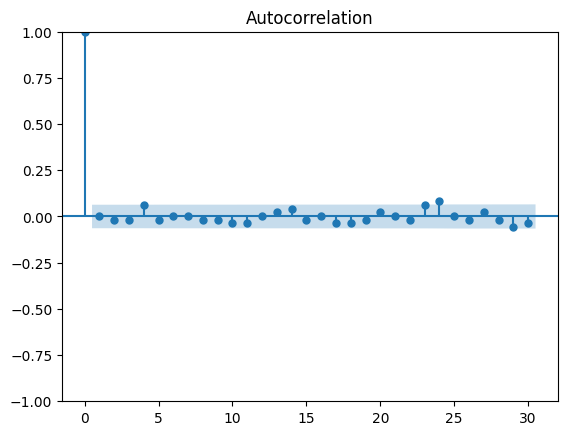

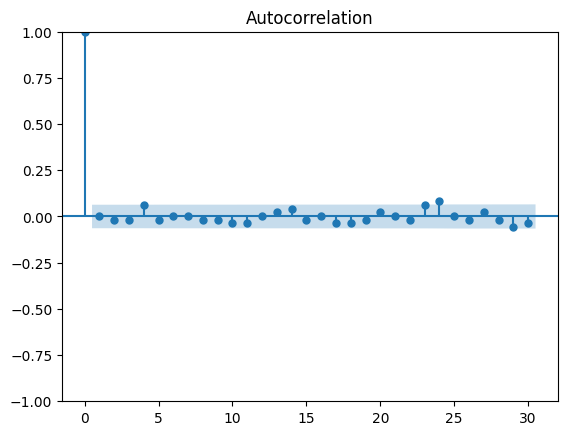

In [42]:
# checking for auto correlations
plot_acf(data_cleaned_outlier["AnyTransplants"])

There is no auto correlation in the variable

In [43]:
# Test for Normaility in the two groups
# null hypothesis = the group follows the normal distribution
# alternative hypothesis = the group dosent follow the null hypothesis
stats_gp0_at,p_value_gp0_at = shapiro(group0_at)
print(f'stats:{stats_gp0_at},p_value:{p_value_gp0_at}')

alpha =0.05
if p_value_gp0_at < alpha:
  print("reject the null hypothesis, the data is not nromally distributed")
else:
  print("fail to reject the null hypothesis, the data is nromally distributed")

stats:0.9144618577538736,p_value:4.622234928420246e-22
reject the null hypothesis, the data is not nromally distributed


In [44]:
# Test for Normaility in the two groups
# null hypothesis = the group follows the normal distribution
# alternative hypothesis = the group dosent follow the null hypothesis
stats_gp1_at,p_value_gp1_at = shapiro(group1_at)
print(f'stats:{stats_gp1_at},p_value:{p_value_gp1_at}')

alpha =0.05
if p_value_gp1_at < alpha:
  print("reject the null hypothesis, the data is not nromally distributed")
else:
  print("fail to reject the null hypothesis, the data is nromally distributed")

stats:0.6570175777567451,p_value:7.286899961591489e-10
reject the null hypothesis, the data is not nromally distributed


The data is not following the  normal distribution

In [45]:
# Performing the non parametric test
# null hypothesis = there is no significant difference between the groups
# alternative hypothesis = there is significant difference between the groups
stats_at_non,p_value_at_non = mannwhitneyu(group0_at,group1_at)
print(f'stats:{stats_at_non},p_value{p_value_at_non}')

alpha =0.05
if p_value_at_non < alpha:
  print("reject the null hypotheis, there is significant difference between the groups")
else:
  print("fail to reject the null hypotheis, there is no significant difference between the groups")

stats:10843.5,p_value1.4209773934453757e-11
reject the null hypotheis, there is significant difference between the groups


**AnyChronicDiseases**

In [46]:
# creating groups
group0_acd = data_cleaned_outlier[data_cleaned_outlier["AnyChronicDiseases"]==0]["PremiumPrice"]
group1_acd = data_cleaned_outlier[data_cleaned_outlier["AnyChronicDiseases"]==1]["PremiumPrice"]

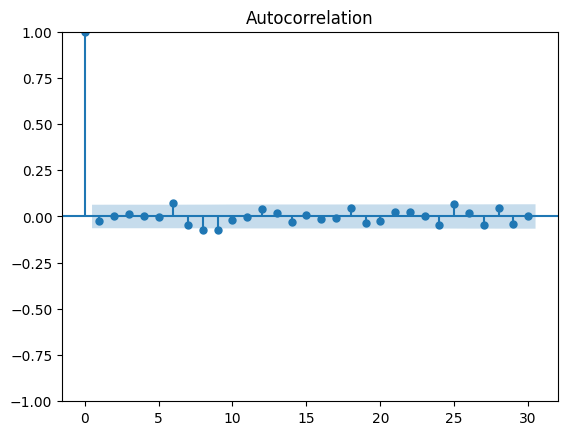

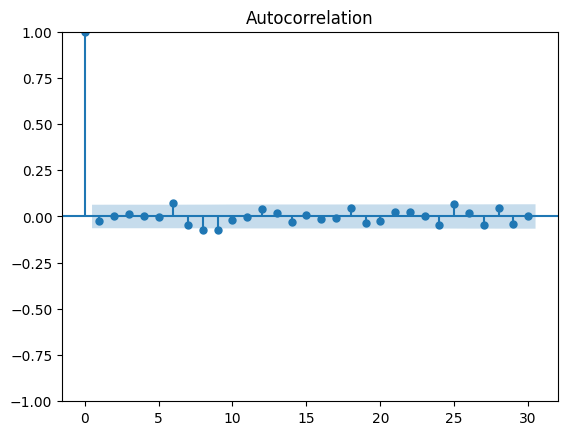

In [47]:
# checking for auto correlations
plot_acf(data_cleaned_outlier["AnyChronicDiseases"])

In [48]:
# Test for Normaility in the two groups
# null hypothesis = the group follows the normal distribution
# alternative hypothesis = the group dosent follow the null hypothesis
stats_gp0_acd,p_value_gp0_acd = shapiro(group0_acd)
print(f'stats:{stats_gp0_acd},p_value:{p_value_gp0_acd}')


alpha =0.05
if p_value_gp0_acd < alpha:
  print("reject the null hypothesis, the data is not nromally distributed")
else:
  print("fail to reject the null hypothesis, the data is nromally distributed")

stats:0.9070762192197975,p_value:2.7328626182827497e-21
reject the null hypothesis, the data is not nromally distributed


In [49]:
# Test for Normaility in the two groups
# null hypothesis = the group follows the normal distribution
# alternative hypothesis = the group dosent follow the null hypothesis
stats_gp1_acd,p_value_gp1_acd = shapiro(group1_acd)
print(f'stats:{stats_gp1_acd},p_value:{p_value_gp1_acd}')


alpha =0.05
if p_value_gp1_acd < alpha:
  print("reject the null hypothesis, the data is not nromally distributed")
else:
  print("fail to reject the null hypothesis, the data is nromally distributed")

stats:0.9369136272305119,p_value:5.542573320387295e-07
reject the null hypothesis, the data is not nromally distributed


In [50]:
# Performing the non parametric test
# null hypothesis = there is no significant difference between the groups
# alternative hypothesis = there is significant difference between the groups
stats_acd_non,p_value_acd_non = mannwhitneyu(group0_acd,group1_acd)
print(f'stats:{stats_acd_non},p_value{p_value_acd_non}')

alpha =0.05
if p_value_acd_non < alpha:
  print("reject the null hypotheis, there is significant difference between the groups")
else:
  print("fail to reject the null hypotheis, there is no significant difference between the groups")

stats:45946.5,p_value8.44586874855364e-12
reject the null hypotheis, there is significant difference between the groups


**`KnownAllergies`**

In [51]:
group0_ka = data_cleaned_outlier[data_cleaned_outlier["KnownAllergies"]==0]["PremiumPrice"]
group1_ka = data_cleaned_outlier[data_cleaned_outlier["KnownAllergies"]==1]["PremiumPrice"]

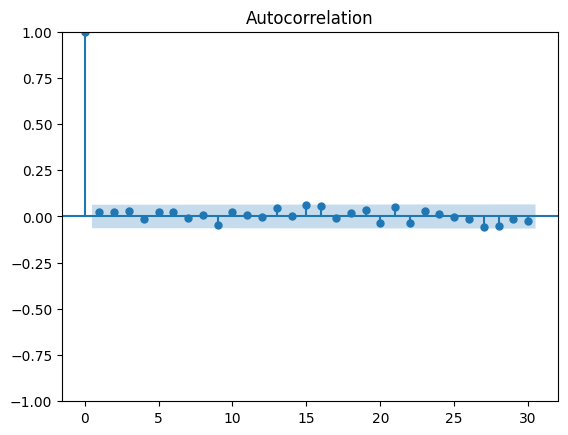

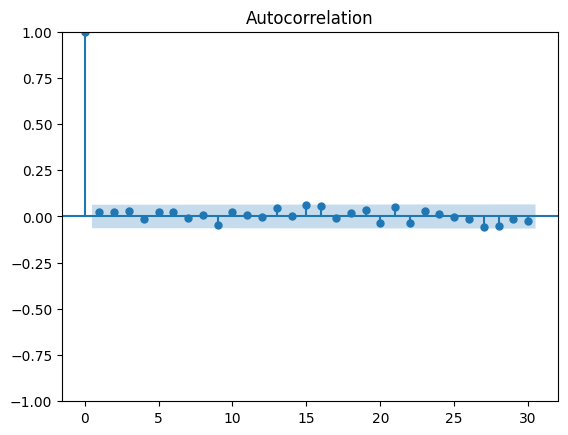

In [52]:
#checking for auto correlation
plot_acf(data_cleaned_outlier["KnownAllergies"])

In [53]:
#test for normality
# null hypothesis = the data frollow the normal distribution
# alternate hypothesis = the data doesnt follow the normal distribution
stats_gp0_ka,p_value_gp0_ka = shapiro(group0_ka)
print(f'stats:{stats_gp0_ka},p_value:{p_value_gp0_ka}')

alpha = 0.05

if p_value_gp0_ka < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
else:
  print("fail to reject null hypothesis, the data is normally distributed")

stats:0.9230210218897529,p_value:5.133781117593311e-19
reject the null hypothesis, the data is not normally distributed


In [54]:
#test for normality
# null hypothesis = the data frollow the normal distribution
# alternate hypothesis = the data doesnt follow the normal distribution
stats_gp1_ka,p_value_gp1_ka = shapiro(group1_ka)
print(f'stats:{stats_gp1_ka},p_value:{p_value_gp1_ka}')

alpha = 0.05

if p_value_gp1_ka < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
else:
  print("fail to reject null hypothesis, the data is normally distributed")

stats:0.925415558880987,p_value:9.420568203906577e-09
reject the null hypothesis, the data is not normally distributed


The data is not normally distribution

In [55]:
#non-parametric test
#null hypothesis = there is no significant difference between the group
#alternative hypothesis = there is significant different between the group

stats_ka_non,p_value_ka_non = mannwhitneyu(group0_ka,group1_ka)
print(f'stats:{stats_ka_non},p_value:{p_value_ka_non}')

alpha = 0.05

if p_value_ka_non < alpha:
  print("reject the null hypothesis, there is significant difference between the groups")
else:
  print("fail to reject the null hypothesis, there is no significant difference between the groups")

stats:74287.5,p_value:0.46501354066545864
fail to reject the null hypothesis, there is no significant difference between the groups


There is no price difference Between the two groups

**History Of Cancer In Family**

In [56]:
group0_hc = data_cleaned_outlier[data_cleaned_outlier["HistoryOfCancerInFamily"]==0]["PremiumPrice"]
group1_hc = data_cleaned_outlier[data_cleaned_outlier["HistoryOfCancerInFamily"]==1]["PremiumPrice"]

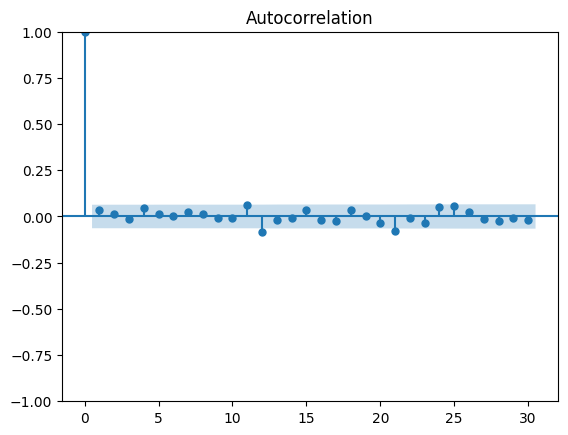

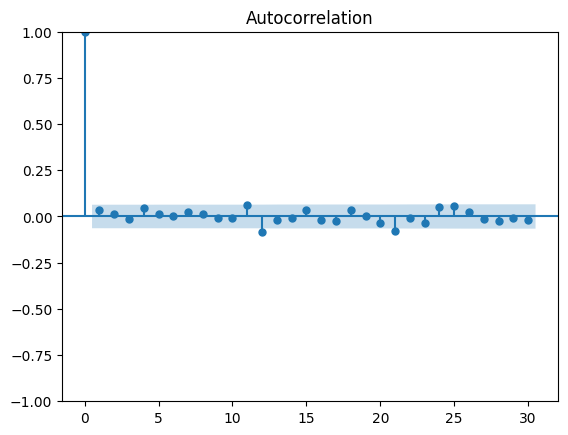

In [57]:
#auto correlation test
plot_acf(data_cleaned_outlier["HistoryOfCancerInFamily"])

In [58]:
# checking the group is normally
# null hypothesis = the groups follow the normal distribution
# alternative hypothesis = the groups dosent follow the normal distribution

stats_gp0_hc,p_value_gp0_hc = shapiro(group0_hc)
print(f'stats:{stats_gp0_hc},p_value = {p_value_gp0_hc}')

alpha = 0.05
if p_value_gp0_hc < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
else:
  print("fail to reject the null hypothesis, the data is normally distributed")

stats:0.9188806228237332,p_value = 9.135156217501461e-21
reject the null hypothesis, the data is not normally distributed


In [59]:
# checking the group is normally
# null hypothesis = the groups follow the normal distribution
# alternative hypothesis = the groups dosent follow the normal distribution

stats_gp1_hc,p_value_gp1_hc = shapiro(group1_hc)
print(f'stats:{stats_gp1_hc},p_value = {p_value_gp1_hc}')

alpha = 0.05
if p_value_gp1_hc < alpha:
  print("reject the null hypothesis, the data is not normally distributed")
else:
  print("fail to reject the null hypothesis, the data is normally distributed")

stats:0.8724185753259427,p_value = 2.044786914534884e-08
reject the null hypothesis, the data is not normally distributed


The data is not following the normal distribution so that we cant perfrom the ttest because one of the assumption got failed.

In [60]:
#Non parametric test
#Null hypothesis = there is no difference between the group
#alternative hypothesis = there is dieffrence between the two groups
stats_hc_non,p_value_hc_non = mannwhitneyu(group0_hc,group1_hc)
print(f'stats:{stats_hc_non},p_value:{p_value_hc_non}')

alpha = 0.05

if p_value_hc_non < alpha:
  print("reject the null hypothesis, there is significant difference between the two groups")
else:
  print("fail to reject the null hypothesis, there is no significant difference between the two groups")


stats:36408.5,p_value:5.834619704485368e-05
reject the null hypothesis, there is significant difference between the two groups


**Number Of Major Surgeries**

In [61]:
group0_s = data_cleaned_outlier[data_cleaned_outlier["NumberOfMajorSurgeries"]==0]["PremiumPrice"]
group1_s = data_cleaned_outlier[data_cleaned_outlier["NumberOfMajorSurgeries"]==1]["PremiumPrice"]
group2_s = data_cleaned_outlier[data_cleaned_outlier["NumberOfMajorSurgeries"]==2]["PremiumPrice"]

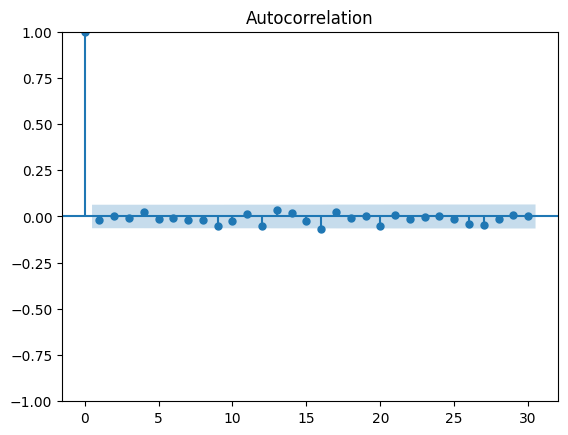

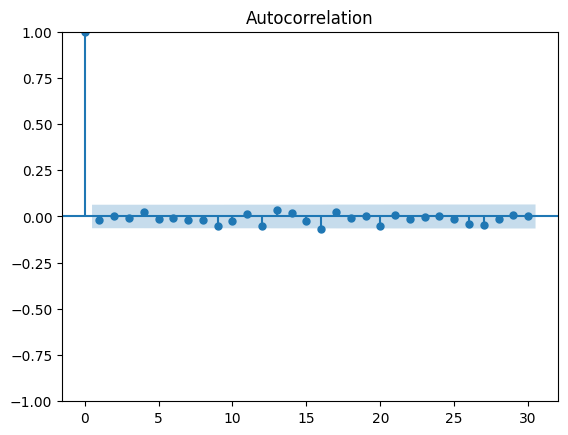

In [62]:
#auto correlation test
plot_acf(data_cleaned_outlier["NumberOfMajorSurgeries"])

In [63]:
#shapiro wil test, normality test
#Null Hypothesis = the groups is normall distributed
#Alternative Hypothesis = the groups is not normall distributed

stats_gp0_s,p_value_gp0_s= shapiro(group0_s)
print(f'stats:{stats_gp0_s},p_value:{p_value_gp0_s}')

alpha =0.05
if p_value_gp0_s < alpha:
  print("reject the null hypothesis, the data is not naomally distributed")
else:
  print("fail to reject the null hypothesis, the data is naomally distributed")

stats:0.888940588559843,p_value:6.3993279649316296e-18
reject the null hypothesis, the data is not naomally distributed


In [64]:
#shapiro wil test, normality test
#Null Hypothesis = the groups is normall distributed
#Alternative Hypothesis = the groups is not normall distributed

stats_gp1_s,p_value_gp1_s= shapiro(group1_s)
print(f'stats:{stats_gp1_s},p_value:{p_value_gp1_s}')

alpha =0.05
if p_value_gp1_s < alpha:
  print("reject the null hypothesis, the data is not naomally distributed")
else:
  print("fail to reject the null hypothesis, the data is naomally distributed")

stats:0.9294307298477866,p_value:4.49874678489162e-12
reject the null hypothesis, the data is not naomally distributed


The data is not following the normal distribution so that we cant perfrom the ttest because one of the assumption got failed.

In [65]:
#shapiro wil test, normality test
#Null Hypothesis = the groups is normall distributed
#Alternative Hypothesis = the groups is not normall distributed

stats_gp2_s,p_value_gp2_s= shapiro(group2_s)
print(f'stats:{stats_gp2_s},p_value:{p_value_gp2_s}')

alpha =0.05
if p_value_gp2_s < alpha:
  print("reject the null hypothesis, the data is not naomally distributed")
else:
  print("fail to reject the null hypothesis, the data is naomally distributed")

stats:0.06717533527065278,p_value:8.16445930028136e-24
reject the null hypothesis, the data is not naomally distributed


**Non Parametric test**

In [66]:
# Non-parametric Test
# Null Hypothesis = there is no difference between two groups
# alternative hypothesis = there is difference between two groups

stats_s_non,p_value_s_non = mannwhitneyu(group0_s,group1_s)
print(f'stats:{stats_s_non},p_value:{p_value_s_non}')

alpha = 0.05

if p_value_s_non < alpha:
  print("reject the null hypothesis, there is significant difference between the two groups")
else:
  print("fail to reject the null hypothesis, there is no significant difference between the two groups")

stats:70713.5,p_value:1.4975290257886314e-05
reject the null hypothesis, there is significant difference between the two groups


#**Performing ChiSquare Test for categorical**

**Any chronic Diseases**

In [67]:
contengeny_table_chronic_Transplant = pd.crosstab(data_cleaned_outlier["AnyChronicDiseases"],data_cleaned_outlier["AnyTransplants"])
contengeny_table_chronic_Transplant

AnyTransplants,0,1
AnyChronicDiseases,,
0,733,40
1,163,13


In [68]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_chronic_Transplant)
chi_value,p_value,dof,expected

(np.float64(0.9435713864533584),
 np.float64(0.3313610617652979),
 1,
 array([[729.82929399,  43.17070601],
        [166.17070601,   9.82929399]]))

In [69]:
alpha = 0.05
if p_value < alpha:
  print("reject the null hypothesis, There is significant association between AnyChronicDiseases and the AnyTransplant")
else:
  print("Fail to reject the null hypothesis, There is no significant association between AnyChronicDiseases and the AnyTransplant")

Fail to reject the null hypothesis, There is no significant association between AnyChronicDiseases and the AnyTransplant


In [70]:
contengeny_table_chronic_Bp = pd.crosstab(data_cleaned_outlier["AnyChronicDiseases"],data_cleaned_outlier["BloodPressureProblems"])
contengeny_table_chronic_Bp

BloodPressureProblems,0,1
AnyChronicDiseases,,
0,417,356
1,86,90


In [71]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_chronic_Bp)
chi_value,p_value,dof,expected

(np.float64(1.289363886520706),
 np.float64(0.2561652113592225),
 1,
 array([[409.71443625, 363.28556375],
        [ 93.28556375,  82.71443625]]))

In [72]:
alpha = 0.05
if p_value < alpha:
  print("reject the null hypothesis, There is significant association between AnyChronicDiseases and the Blood Pressure Problems")
else:
  print("Fail to reject the null hypothesis, There is no significant association between AnyChronicDiseases and the Blood Pressure Problems")

Fail to reject the null hypothesis, There is no significant association between AnyChronicDiseases and the Blood Pressure Problems


In [73]:
contengeny_table_chronic_Diabetes = pd.crosstab(data_cleaned_outlier["AnyChronicDiseases"],data_cleaned_outlier["Diabetes"])
contengeny_table_chronic_Diabetes

Diabetes,0,1
AnyChronicDiseases,,
0,436,337
1,119,57


In [74]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_chronic_Diabetes)
chi_value,p_value,dof,expected

(np.float64(6.965110358763361),
 np.float64(0.008311430641932589),
 1,
 array([[452.07060063, 320.92939937],
        [102.92939937,  73.07060063]]))

In [75]:
alpha=0.05
if p_value < alpha:
  print("reject the null hypothesis, there is significant association between AnyChronicDiseases and Diabetes")
else:
  print("Fail to reject the null hypothesis, there no is significant association between AnyChronicDiseases and Diabetes")

# There is connection between two variables

reject the null hypothesis, there is significant association between AnyChronicDiseases and Diabetes


In [76]:
contengeny_table_chronic_cancer = pd.crosstab(data_cleaned_outlier["AnyChronicDiseases"],data_cleaned_outlier["HistoryOfCancerInFamily"])
contengeny_table_chronic_cancer

HistoryOfCancerInFamily,0,1
AnyChronicDiseases,,
0,682,91
1,154,22


In [77]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_chronic_cancer)
p_value,dof

(np.float64(0.8885974956544036), 1)

In [78]:
alpha=0.05
if p_value < alpha:
  print("reject the null hypothesis, there is significant association between AnyChronicDiseases and cancer")
else:
  print("Fail to reject the null hypothesis, there no is significant association between AnyChronicDiseases and cancer")

Fail to reject the null hypothesis, there no is significant association between AnyChronicDiseases and cancer


In [79]:
contengeny_table_chronic_Allergies = pd.crosstab(data_cleaned_outlier["AnyChronicDiseases"],data_cleaned_outlier["KnownAllergies"])
contengeny_table_chronic_Allergies

KnownAllergies,0,1
AnyChronicDiseases,,
0,600,173
1,142,34


In [80]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_chronic_Allergies)
p_value,dof

(np.float64(0.4314642683094694), 1)

In [81]:
alpha=0.05
if p_value < alpha:
  print("reject the null hypothesis, there is significant association between AnyChronicDiseases and Allergies")
else:
  print("Fail to reject the null hypothesis, there no is significant association between AnyChronicDiseases and Allergies")

Fail to reject the null hypothesis, there no is significant association between AnyChronicDiseases and Allergies


**Any Transplant**

In [82]:
contengeny_table_transplant_bp = pd.crosstab(data_cleaned_outlier["AnyTransplants"],data_cleaned_outlier["BloodPressureProblems"])
contengeny_table_transplant_bp

BloodPressureProblems,0,1
AnyTransplants,,
0,472,424
1,31,22


In [83]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_transplant_bp)
p_value,dof

(np.float64(0.49515295866414244), 1)

In [84]:
alpha=0.05
if p_value < alpha:
  print("reject the null hypothesis, there is significant association between transplant and bp")
else:
  print("Fail to reject the null hypothesis, there no is significant association between transplant and bp")

Fail to reject the null hypothesis, there no is significant association between transplant and bp


In [85]:
contengeny_table_transplant_Diabetes = pd.crosstab(data_cleaned_outlier["AnyTransplants"],data_cleaned_outlier["Diabetes"])
contengeny_table_transplant_Diabetes

Diabetes,0,1
AnyTransplants,,
0,520,376
1,35,18


In [86]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_transplant_Diabetes)
p_value,dof

(np.float64(0.3147436861083972), 1)

In [87]:
alpha= 0.05
if p_value < alpha:
  print("reject the null hypothesis, there is singificant association between transplant and Diabetes")
else:
  print("Fail to reject the null hypothesis, there is no singificant association between transplant and Diabetes")

Fail to reject the null hypothesis, there is no singificant association between transplant and Diabetes


In [88]:
contengeny_table_transplant_cancer = pd.crosstab(data_cleaned_outlier["AnyTransplants"],data_cleaned_outlier["HistoryOfCancerInFamily"])
contengeny_table_transplant_cancer

HistoryOfCancerInFamily,0,1
AnyTransplants,,
0,788,108
1,48,5


In [89]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_transplant_cancer)
p_value,dof

(np.float64(0.7233974180761966), 1)

In [90]:
alpha= 0.05
if p_value < alpha:
  print("reject the null hypothesis, there is singificant association between transplant and cancer")
else:
  print("Fail to reject the null hypothesis, there is no singificant association between transplant and cancer")

Fail to reject the null hypothesis, there is no singificant association between transplant and cancer


In [91]:
contengeny_table_transplant_Allergies = pd.crosstab(data_cleaned_outlier["AnyTransplants"],data_cleaned_outlier["KnownAllergies"])
contengeny_table_transplant_Allergies

KnownAllergies,0,1
AnyTransplants,,
0,700,196
1,42,11


In [92]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_transplant_Allergies)
p_value,dof

(np.float64(0.9834525601433024), 1)

In [93]:
alpha= 0.05
if p_value < alpha:
  print("reject the null hypothesis, there is singificant association between transplant and Allergies")
else:
  print("Fail to reject the null hypothesis, there is no singificant association between transplant and Allergies")

Fail to reject the null hypothesis, there is no singificant association between transplant and Allergies


**Blood Pressure**

In [94]:
contengeny_table_bp_Diabetes = pd.crosstab(data_cleaned_outlier["BloodPressureProblems"],data_cleaned_outlier["Diabetes"])
contengeny_table_bp_Diabetes

Diabetes,0,1
BloodPressureProblems,,
0,326,177
1,229,217


In [95]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_bp_Diabetes)
p_value,dof

(np.float64(3.538934213596045e-05), 1)

In [96]:
alpha = 0.05
if p_value<alpha:
  print("reject the null hypothesis, there is significant association between Bp and diabetes")
else:
  print("fail to reject the null hypothesis, there is no significant association between Bp and diabetes")

reject the null hypothesis, there is significant association between Bp and diabetes


In [97]:
contengeny_table_bp_cancer = pd.crosstab(data_cleaned_outlier["BloodPressureProblems"],data_cleaned_outlier["HistoryOfCancerInFamily"])
contengeny_table_bp_cancer

HistoryOfCancerInFamily,0,1
BloodPressureProblems,,
0,451,52
1,385,61


In [98]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_bp_cancer)
p_value,dof

(np.float64(0.1376041549773562), 1)

In [99]:
alpha = 0.05
if p_value<alpha:
  print("reject the null hypothesis, there is significant association between Bp and cancer")
else:
  print("fail to reject the null hypothesis, there is no significant association between Bp and cancer")

fail to reject the null hypothesis, there is no significant association between Bp and cancer


In [100]:
contengeny_table_bp_Allergies = pd.crosstab(data_cleaned_outlier["BloodPressureProblems"],data_cleaned_outlier["KnownAllergies"])
contengeny_table_bp_Allergies

KnownAllergies,0,1
BloodPressureProblems,,
0,390,113
1,352,94


In [101]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_bp_Allergies)
p_value,dof

(np.float64(0.6611149085727988), 1)

In [102]:
alpha = 0.05
if p_value<alpha:
  print("reject the null hypothesis, there is significant association between Bp and Allergies")
else:
  print("fail to reject the null hypothesis, there is no significant association between Bp and Allergies")

fail to reject the null hypothesis, there is no significant association between Bp and Allergies


**Diabetes**

In [103]:
contengeny_table_Diabetes_cancer = pd.crosstab(data_cleaned_outlier["Diabetes"],data_cleaned_outlier["HistoryOfCancerInFamily"])
contengeny_table_Diabetes_cancer

HistoryOfCancerInFamily,0,1
Diabetes,,
0,482,73
1,354,40


In [104]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_Diabetes_cancer)
p_value,dof

(np.float64(0.1919699955549817), 1)

In [105]:
alpha = 0.05
if p_value<alpha:
  print("reject the null hypothesis, there is significant association between Bp and cancer")
else:
  print("fail to reject the null hypothesis, there is no significant association between Bp and cancer")

fail to reject the null hypothesis, there is no significant association between Bp and cancer


In [106]:
contengeny_table_Diabetes_Allergies = pd.crosstab(data_cleaned_outlier["Diabetes"],data_cleaned_outlier["KnownAllergies"])
contengeny_table_Diabetes_Allergies

KnownAllergies,0,1
Diabetes,,
0,420,135
1,322,72


In [107]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_Diabetes_Allergies)
p_value,dof

(np.float64(0.03202336090095763), 1)

In [108]:
alpha = 0.05
if p_value<alpha:
  print("reject the null hypothesis, there is significant association between Diabetes and Allergies")
else:
  print("fail to reject the null hypothesis, there is no significant association between Diabetes and Allergies")

reject the null hypothesis, there is significant association between Diabetes and Allergies


**History Of Cancer**

In [109]:
contengeny_table_cancer_Allergies = pd.crosstab(data_cleaned_outlier["HistoryOfCancerInFamily"],data_cleaned_outlier["KnownAllergies"])
contengeny_table_cancer_Allergies

KnownAllergies,0,1
HistoryOfCancerInFamily,,
0,668,168
1,74,39


In [110]:
chi_value,p_value,dof,expected = chi2_contingency(contengeny_table_cancer_Allergies)
p_value,dof

(np.float64(0.0007741696478583031), 1)

In [111]:
alpha = 0.05
if p_value<alpha:
  print("reject the null hypothesis, there is significant association between cancer and Allergies")
else:
  print("fail to reject the null hypothesis, there is no significant association between cancer and Allergies")

reject the null hypothesis, there is significant association between cancer and Allergies


## Regression Analysis

In [112]:
cat_col_cleaned = data_cleaned_outlier[['AnyChronicDiseases', 'AnyTransplants', 'BloodPressureProblems',
       'Diabetes', 'HistoryOfCancerInFamily', 'KnownAllergies']]

In [113]:
num_col_cleaned = data_cleaned_outlier[['Age', 'NumberOfMajorSurgeries' ,'PremiumPrice', 'Height', 'Weight']]

In [114]:
num_col_1 = num_col_cleaned.copy()
cat_col_1 = cat_col_cleaned.copy()

In [115]:
cat_col_1.describe(include="object")

,AnyChronicDiseases,AnyTransplants,BloodPressureProblems,Diabetes,HistoryOfCancerInFamily,KnownAllergies
count,949,949,949,949,949,949
unique,2,2,2,2,2,2
top,0,0,0,0,0,0
freq,773,896,503,555,836,742


In [116]:
cat_col_1.shape

(949, 6)

#**Feature Engineering**

**Performing onehot encoding**

In [117]:
# Now with one hot encoding
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop = 'first', sparse_output=False)
encoded = ohe.fit_transform(cat_col_1)
encoded

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.]])

In [118]:
# getting out the feature names
ohe.get_feature_names_out()

array(['AnyChronicDiseases_1', 'AnyTransplants_1',
       'BloodPressureProblems_1', 'Diabetes_1',
       'HistoryOfCancerInFamily_1', 'KnownAllergies_1'], dtype=object)

In [119]:
# creating a data frame
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out())
encoded_df.shape

(949, 6)

In [120]:
df_final = pd.concat([num_col_1,encoded_df],axis=1, ignore_index=False)

In [121]:
df_final.shape

(949, 11)

In [122]:
import statsmodels.api as sm

In [123]:
X_final = df_final.drop(["PremiumPrice","Height"],axis=1)
y_final = df_final["PremiumPrice"]

In [124]:
X= sm.add_constant(X_final)

# Fit the model

model = sm.OLS(y_final,X_final).fit()

#summary
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:           PremiumPrice   R-squared (uncentered):                   0.981
Model:                            OLS   Adj. R-squared (uncentered):              0.980
Method:                 Least Squares   F-statistic:                              5293.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                        0.00
Time:                        10:43:05   Log-Likelihood:                         -9083.2
No. Observations:                 949   AIC:                                  1.818e+04
Df Residuals:                     940   BIC:                                  1.823e+04
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------

In [125]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#vif dataframe
vif_data = pd.DataFrame()
vif_data["Features"] = X_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_final.values,i)
                  for i in range(X_final.shape[1])]

In [126]:
print(vif_data)

                    Features        VIF
0                        Age  10.696624
1     NumberOfMajorSurgeries   2.479654
2                     Weight   8.666549
3       AnyChronicDiseases_1   1.243965
4           AnyTransplants_1   1.060368
5    BloodPressureProblems_1   2.147930
6                 Diabetes_1   1.814408
7  HistoryOfCancerInFamily_1   1.235243
8           KnownAllergies_1   1.329186


**Data Preprocessing**

In [127]:
# converting the height from centimeter to meter
data_cleaned_outlier["Height"] = data_cleaned_outlier["Height"]/100
data_cleaned_outlier["BMI"] = round(data_cleaned_outlier["Weight"]/(data_cleaned_outlier["Height"]**2),2)

In [128]:
data_cleaned_outlier.drop(["Height","Weight"],axis=1,inplace=True)

In [129]:
data_cleaned_outlier.sample(3)

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI
376,43,0,0,0,0,0,0,1,23000,17.51
295,55,1,0,1,0,0,0,0,38000,33.62
41,25,0,1,0,0,0,1,1,15000,16.25


In [130]:
def bmi_category (BMI) :
  if BMI < 18.5:
    return "Under Weight"
  elif  18.5 <= BMI <= 24.9:
    return "Normal"
  elif 25 <= BMI <= 29.9:
    return "Overweight"
  else:
    return "Obese"

In [131]:
data_cleaned_outlier["BMI_Category"] = data_cleaned_outlier["BMI"].apply(bmi_category)

In [132]:
data_cleaned_outlier.sample(3)

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category
570,27,0,0,0,0,1,0,1,15000,30.45,Obese
465,59,1,1,0,0,0,0,1,25000,22.20,Normal
780,62,1,0,0,0,0,0,0,29000,32.05,Obese


In [133]:
data_cleaned_outlier["BMI_Category"].value_counts()

,count
BMI_Category,
Normal,312
Overweight,310
Obese,290
Under Weight,37


# Scaling and Encoding


*   Scaling is for Numerical features.

*   encoding is for categorincal Variable

In [134]:
new_num_col = data_cleaned_outlier[["Age","BMI","NumberOfMajorSurgeries"]]

In [135]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaler = scaler.fit_transform(new_num_col)

In [136]:
X_scaler_df = pd.DataFrame(X_scaler,columns=new_num_col.columns)
X_scaler_df.sample(5)

,Age,BMI,NumberOfMajorSurgeries
744,-0.107955,0.365668,-0.906526
700,0.257153,-1.541090,-0.906526
466,-1.057236,-1.508246,-0.906526
359,-1.641409,1.622851,-0.906526
894,1.498520,-0.048527,-0.906526


In [137]:
X_scaler_final = pd.concat([X_scaler_df,encoded_df],axis=1,ignore_index=False)

In [138]:
X_scaler_final.sample(3)

,Age,BMI,NumberOfMajorSurgeries,AnyChronicDiseases_1,AnyTransplants_1,BloodPressureProblems_1,Diabetes_1,HistoryOfCancerInFamily_1,KnownAllergies_1
763,-0.400041,-0.917060,-0.906526,0.0,0.0,0.0,1.0,0.0,0.0
887,1.790607,-1.156089,1.985215,0.0,0.0,1.0,1.0,0.0,0.0
919,-1.203279,-0.099617,0.539345,0.0,1.0,0.0,0.0,0.0,1.0


In [139]:
vif_data = pd.DataFrame()
vif_data["Features"] = X_scaler_final.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaler_final.values,i)
                  for i in range(X_scaler_final.shape[1])]

In [140]:
print(vif_data)

                    Features       VIF
0                        Age  1.242846
1                        BMI  1.006269
2     NumberOfMajorSurgeries  1.302869
3       AnyChronicDiseases_1  1.144304
4           AnyTransplants_1  1.039155
5    BloodPressureProblems_1  1.619381
6                 Diabetes_1  1.415967
7  HistoryOfCancerInFamily_1  1.190109
8           KnownAllergies_1  1.180625


#**Machine Learning Modeling**

#Linear Regression

In [141]:
from sklearn.model_selection import cross_val_score,KFold

In [142]:
X = X_scaler_final
y = data_cleaned_outlier["PremiumPrice"]

In [143]:
X.sample(3)

,Age,BMI,NumberOfMajorSurgeries,AnyChronicDiseases_1,AnyTransplants_1,BloodPressureProblems_1,Diabetes_1,HistoryOfCancerInFamily_1,KnownAllergies_1
335,0.257153,-0.026631,-0.906526,1.0,0.0,0.0,0.0,0.0,0.0
175,-0.253998,-0.398860,0.539345,1.0,0.0,0.0,0.0,0.0,1.0
833,-1.203279,-0.548481,-0.906526,0.0,1.0,0.0,0.0,0.0,0.0


In [144]:
# Train Test Split the data
X_train_lr,X_test_lr,y_train_lr,y_test_lr = train_test_split(X,y, test_size=0.2,random_state=42)

In [145]:
X_train_lr.shape,X_test_lr.shape,y_train_lr.shape,y_test_lr.shape

((759, 9), (190, 9), (759,), (190,))

In [146]:
model = LinearRegression()
model.fit(X_train_lr,y_train_lr)

LinearRegression()

In [147]:
# Train dataset scores for Linear Regression
y_pred_lr_Train = model.predict(X_train_lr)

print(f'r_2 Score :{r2_score(y_train_lr,y_pred_lr_Train)}')
print(f'MSE Score : {mean_squared_error(y_train_lr , y_pred_lr_Train)}')
print(f'RMSE_Score : {np.sqrt(mean_squared_error(y_train_lr,y_pred_lr_Train))}')

r_2 Score :0.6854738578017072
MSE Score : 11659830.965938417
RMSE_Score : 3414.649464577355


In [148]:
#Test dataset scores for Linear Regression
y_pred_lr_test = model.predict(X_test_lr)

print(f'r_2 Score :{r2_score(y_test_lr,y_pred_lr_test)}')
print(f'MSE Score : {mean_squared_error(y_test_lr,y_pred_lr_test)}')
print(f'RMSE_Score : {np.sqrt(mean_squared_error(y_test_lr,y_pred_lr_test))}')

r_2 Score :0.6338013289363198
MSE Score : 14885205.034167938
RMSE_Score : 3858.1349165325905


# Decision Tree

In [149]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector

In [150]:
data_cleaned_outlier.sample(3)

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice,BMI,BMI_Category
504,28,0,0,0,0,0,0,0,15000,23.96,Normal
810,56,1,1,0,1,0,0,2,28000,23.34,Normal
257,28,0,0,0,1,0,1,1,21000,19.66,Normal


In [151]:
X_dt = data_cleaned_outlier.drop(["PremiumPrice","BMI_Category"], axis = 1)
y_dt = data_cleaned_outlier["PremiumPrice"]

In [152]:
X_train_dt,X_test_dt,y_train_dt,y_test_dt = train_test_split(X_dt,y_dt, test_size=0.2,random_state=42)
regressor = DecisionTreeRegressor(random_state =42)

In [153]:
sfs = SequentialFeatureSelector(regressor,
                                n_features_to_select = 5,
                                direction="forward",
                                scoring="neg_mean_squared_error",
                                cv=5,
                                n_jobs=-1)
sfs.fit(X_train_dt,y_train_dt)

SequentialFeatureSelector(estimator=DecisionTreeRegressor(random_state=42),
                          n_features_to_select=5, n_jobs=-1,
                          scoring='neg_mean_squared_error')

In [154]:
# Get the selected features
selectd_features = X_train_dt.columns[sfs.get_support()]
print(f"Selected Features : {selectd_features}")

Selected Features : Index(['Age', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases',
       'HistoryOfCancerInFamily'],
      dtype='object')


In [155]:
param_grid = {
    "max_depth":[3,4,5],
    "min_samples_split": [5,10,15],
    "min_samples_leaf": [2,5,8]
}

dt_regressor = DecisionTreeRegressor(random_state =42)
grid_search = GridSearchCV(estimator=dt_regressor,
                           param_grid = param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=2,
                           scoring="neg_mean_squared_error")
grid_search.fit(X_train_dt[selectd_features],y_train_dt)
best_dtree_reg = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [156]:
y_pred_dt_train = best_dtree_reg.predict(X_train_dt[selectd_features])
mse = mean_squared_error(y_train_dt,y_pred_dt_train)
print("-------Train Score----------")
best_params = grid_search.best_params_
print(f"Best Parameters : {best_params}")
print(f'r_2 Score :{r2_score(y_train_dt,y_pred_dt_train)}')
print(f'MSE Score : {mse}')
print(f'RMSE_Score : {np.sqrt(mse)}')

-------Train Score----------
Best Parameters : {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 5}
r_2 Score :0.820743085455107
MSE Score : 6645251.515377742
RMSE_Score : 2577.8385355521673


In [157]:
y_pred_dt = best_dtree_reg.predict(X_test_dt[selectd_features])
mse = mean_squared_error(y_test_dt,y_pred_dt)
print("-------Test Score----------")
best_params = grid_search.best_params_
print(f"Best Parameters : {best_params}")
print(f'r_2 Score :{r2_score(y_test_dt,y_pred_dt)}')
print(f'MSE Score : {mse}')
print(f'RMSE_Score : {np.sqrt(mse)}')

-------Test Score----------
Best Parameters : {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 5}
r_2 Score :0.6528210338428875
MSE Score : 14112094.071199976
RMSE_Score : 3756.606722988178


# Random Forest

In [158]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from scipy.stats import randint

In [159]:
base_regressor = RandomForestRegressor(random_state =42)

In [160]:
X_rf = data_cleaned_outlier.drop(["PremiumPrice","BMI_Category"], axis = 1)
y_rf = data_cleaned_outlier["PremiumPrice"]

In [161]:
X_train_rf,X_test_rf,y_train_rf,y_test_rf = train_test_split(X_rf,y_rf, stratify=X_rf["Age"],test_size=0.20,random_state=42)

In [162]:
SfS_rf = SFS(base_regressor,
            k_features = (9, 9),
            forward = True,
            floating = False,
            scoring="neg_mean_squared_error",
            cv=5,
            n_jobs=-1)
SfS_rf.fit(X_train_rf,y_train_rf)

SequentialFeatureSelector(estimator=RandomForestRegressor(random_state=42),
                          k_features=(9, 9), n_jobs=-1,
                          scoring='neg_mean_squared_error')

In [163]:
selectd_features_rf = X_train_rf.columns[list(SfS_rf.k_feature_idx_)]
print(len(selectd_features_rf))
print(f"Selected Features : {selectd_features_rf}")

9
Selected Features : Index(['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'KnownAllergies', 'HistoryOfCancerInFamily',
       'NumberOfMajorSurgeries', 'BMI'],
      dtype='object')


In [164]:
rf = RandomForestRegressor(n_estimators=500,max_depth=4,min_samples_leaf=3,max_features='sqrt',random_state=42,n_jobs=-1,oob_score= True)
rf.fit(X_train_rf[selectd_features_rf],y_train_rf)

RandomForestRegressor(max_depth=4, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=500, n_jobs=-1, oob_score=True,
                      random_state=42)

In [165]:
y_pred_rf_train = rf.predict(X_train_rf[selectd_features_rf])
R2 = r2_score(y_train_rf,y_pred_rf_train)
mse = mean_squared_error(y_train_rf,y_pred_rf_train)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train_rf,y_pred_rf_train)

print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

MSE : 9369894.02540255
RMSE : 3061.028262757884
MAE : 2346.2088460532186


In [166]:
y_pred_rf = rf.predict(X_test_rf[selectd_features_rf])
R2 = r2_score(y_test_rf,y_pred_rf)
mse = mean_squared_error(y_test_rf,y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_rf,y_pred_rf)

print(f"MSE : {mse}")
print(f"RMSE : {rmse}")
print(f"MAE : {mae}")

MSE : 10927339.108526854
RMSE : 3305.652599491794
MAE : 2486.8461277489373


In [167]:
regressor_cv = RandomForestRegressor(random_state=42)

In [168]:
 param_grid_rf = {
     "n_estimators": randint(400,2000),
     "max_depth":randint(2,8),
     "min_samples_split": randint(20,50), # min_samples_split must be at least 2
     "min_samples_leaf": randint(5,20),
     "max_features": ['sqrt', 'log2', None]
 }
 random_search = RandomizedSearchCV(estimator=regressor_cv,
                            param_distributions = param_grid_rf,
                            n_iter = 50,
                            cv=5,
                            n_jobs=-1,
                            verbose=1,
                            random_state=42,
                            scoring="neg_mean_squared_error") # Changed scoring to a regression metric
 random_search.fit(X_train_rf[selectd_features_rf],y_train_rf)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2ac6ce6c0>,
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2a88fe390>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2a88feae0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2a88f6e70>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [169]:
best_rf_reg = random_search.best_estimator_
best_prams = random_search.best_params_

In [170]:
#------------- Train Prediction-------------
y_pred_rf_train = best_rf_reg.predict(X_train_rf[selectd_features_rf])

#------------- Train Evaluation -------------
mse = mean_squared_error(y_train_rf,y_pred_rf_train)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train_rf,y_pred_rf_train)
R2 = r2_score(y_train_rf,y_pred_rf_train)

print("-------Train Score----------")
print(f"Best Parameters: {best_prams}")
print(f"R2 score: {R2}")
print(f"MSE :{mse}")
print(f"RMSE :{rmse}")
print(f"MAE :{mae}")

-------Train Score----------
Best Parameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 24, 'n_estimators': 1641}
R2 score: 0.8439870308556936
MSE :5829777.0437956
RMSE :2414.493123575961
MAE :1358.9015296128491


In [171]:
#------------- Test Prediction-------------
y_pred_rf_test = best_rf_reg.predict(X_test_rf[selectd_features_rf])

#------------- Test Evaluation -------------
mse = mean_squared_error(y_test_rf,y_pred_rf_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_rf,y_pred_rf_test)
R2 = r2_score(y_test_rf,y_pred_rf_test)

print("-------Test Score----------")
print(f"Best Parameters: {best_prams}")
print(f"R2 score: {R2}")
print(f"MSE :{mse}")
print(f"RMSE :{rmse}")
print(f"MAE :{mae}")

-------Test Score----------
Best Parameters: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 24, 'n_estimators': 1641}
R2 score: 0.838160443666497
MSE :6482709.824993721
RMSE :2546.116616534624
MAE :1484.1855387825722


In [172]:
def objective(trial):
    # Define the hyperparameter search space
    n_estimators = trial.suggest_int('n_estimators', 400, 2000)
    max_depth = trial.suggest_int('max_depth', 2, 8)
    min_samples_split = trial.suggest_int('min_samples_split', 5, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 5, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Define model
    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    # Evaluate using cross-validation (5-fold)
    score = cross_val_score(rf, X_train_rf[selectd_features_rf], y_train_rf, cv=5, scoring='neg_mean_squared_error').mean()

    # Optuna tries to maximize objective, so return negative MSE directly
    return score

In [173]:
study = optuna.create_study(direction='maximize')  # because we're minimize neg MSE
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-06-03 10:52:45,162] A new study created in memory with name: no-name-020ac352-3da6-4719-8322-5eae2a151a05


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-03 10:53:06,826] Trial 0 finished with value: -17091912.784583963 and parameters: {'n_estimators': 1966, 'max_depth': 2, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: -17091912.784583963.
[I 2026-06-03 10:53:27,254] Trial 1 finished with value: -11844561.253099207 and parameters: {'n_estimators': 1776, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 1 with value: -11844561.253099207.
[I 2026-06-03 10:53:34,046] Trial 2 finished with value: -17095221.909165107 and parameters: {'n_estimators': 634, 'max_depth': 2, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 1 with value: -11844561.253099207.
[I 2026-06-03 10:53:41,999] Trial 3 finished with value: -8096002.4520502165 and parameters: {'n_estimators': 567, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': None}. Best is trial 3 with value: -8096002.45

In [174]:
print("Best parameters:", study.best_params)
print("Best score (neg MSE):", study.best_value)
print("Best MSE:", abs(study.best_value))
print("Best RMSE:", np.sqrt(abs(study.best_value)))

Best parameters: {'n_estimators': 1990, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None}
Best score (neg MSE): -7241555.691654466
Best MSE: 7241555.691654466
Best RMSE: 2691.0138780122384


In [175]:
best_trial = study.best_trial
best_params = best_trial.params
print("Best Trial: ",best_trial)
print("Best parameters:", best_params)

Best Trial:  FrozenTrial(number=42, state=<TrialState.COMPLETE: 1>, values=[-7241555.691654466], datetime_start=datetime.datetime(2026, 6, 3, 11, 4, 55, 711232), datetime_complete=datetime.datetime(2026, 6, 3, 11, 5, 21, 813811), params={'n_estimators': 1990, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=2000, log=False, low=400, step=1), 'max_depth': IntDistribution(high=8, log=False, low=2, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=5, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=5, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None))}, trial_id=42, value=None)
Best parameters: {'n_estimators': 1990, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None}


In [176]:
# Train the model with the best hyperparameters found by Optuna
best_model = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# Fit the model to the entire training data
best_model.fit( X_train_rf[selectd_features_rf], y_train_rf)


RandomForestRegressor(max_depth=8, max_features=None, min_samples_leaf=5,
                      min_samples_split=6, n_estimators=1990, random_state=42)

In [177]:
y_pred_rf_optuna_train = best_model.predict(X_train_rf[selectd_features_rf])
mse = mean_squared_error(y_train_rf,y_pred_rf_optuna_train)
print("-------Train Score----------")
print(f'r_2 Score :{r2_score(y_train_rf,y_pred_rf_optuna_train)}')
print(f'MSE Score : {mse}')
print(f'RMSE_Score : {np.sqrt(mse)}')

-------Train Score----------
r_2 Score :0.8740725587879147
MSE Score : 4705563.3258482
RMSE_Score : 2169.231044828605


In [178]:
y_pred_rf_optuna_test = best_model.predict(X_test_rf[selectd_features_rf])
mse = mean_squared_error(y_test_rf,y_pred_rf_optuna_test)
print("-------Test Score----------")
print(f'r_2 Score :{r2_score(y_test_rf,y_pred_rf_optuna_test)}')
print(f'MSE Score : {mse}')
print(f'RMSE_Score : {np.sqrt(mse)}')

-------Test Score----------
r_2 Score :0.8357751605047881
MSE Score : 6578255.6787894275
RMSE_Score : 2564.811041536867


In [179]:
print("=" * 45)
print("       Random Forest Model Summary")
print("=" * 45)
print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
print("-" * 45)
print(f"{'R2 Score':<15} {r2_score(y_train_rf, y_pred_rf_optuna_train):>10.4f} {r2_score(y_test_rf, y_pred_rf_optuna_test):>10.4f}")
print(f"{'MSE':<15} {mean_squared_error(y_train_rf, y_pred_rf_optuna_train):>10.0f} {mean_squared_error(y_test_rf, y_pred_rf_optuna_test):>10.0f}")
print(f"{'RMSE':<15} {np.sqrt(mean_squared_error(y_train_rf, y_pred_rf_optuna_train)):>10.2f} {np.sqrt(mean_squared_error(y_test_rf, y_pred_rf_optuna_test)):>10.2f}")
print(f"{'MAE':<15} {mean_absolute_error(y_train_rf, y_pred_rf_optuna_train):>10.2f} {mean_absolute_error(y_test_rf, y_pred_rf_optuna_test):>10.2f}")
print("=" * 45)

       Random Forest Model Summary
Metric               Train       Test
---------------------------------------------
R2 Score            0.8741     0.8358
MSE                4705563    6578256
RMSE               2169.23    2564.81
MAE                1162.53    1368.56


# Gradient Boosting

## Implement Gradient Boosting Regressor

### Subtask:
Implement Sequential Feature Selection for the Gradient Boosting model.

In [180]:
# ✅ CORRECT — includes all numerical features
data_gb = pd.concat([
    data_cleaned_outlier[["Age", "BMI", "NumberOfMajorSurgeries", "PremiumPrice"]],
    encoded_df
], axis=1)

In [181]:
data_gb.shape

(949, 10)

In [182]:
X_gb = data_gb.drop(["PremiumPrice"],axis=1)
y_gb = data_gb["PremiumPrice"]

In [183]:
X_train_gb,X_test_gb,y_train_gb,y_test_gb = train_test_split(X_gb,y_gb,test_size=0.20,random_state=42,stratify=X_gb["Age"])

In [184]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
selected_features_gbr = ['Age', 'BMI', 'NumberOfMajorSurgeries',
                         'AnyChronicDiseases_1', 'AnyTransplants_1',
                         'BloodPressureProblems_1', 'Diabetes_1',
                         'HistoryOfCancerInFamily_1', 'KnownAllergies_1']

print(f"Total features: {len(selected_features_gbr)}")
print(f"Features: {selected_features_gbr}")

Total features: 9
Features: ['Age', 'BMI', 'NumberOfMajorSurgeries', 'AnyChronicDiseases_1', 'AnyTransplants_1', 'BloodPressureProblems_1', 'Diabetes_1', 'HistoryOfCancerInFamily_1', 'KnownAllergies_1']


In [185]:
param_dist_gbr = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 8),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
}

gbr_regressor_tuned = GradientBoostingRegressor(random_state=42)

random_search_gbr = RandomizedSearchCV(
    estimator=gbr_regressor_tuned,
    param_distributions=param_dist_gbr,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_gbr.fit(X_train_gb[selected_features_gbr], y_train_gb)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7be2a888ede0>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2acb86de0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2acb86d20>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2acb87620>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7be2acb84500>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [186]:
print(selected_features_gbr)
print(X_train_gb.columns.tolist())

['Age', 'BMI', 'NumberOfMajorSurgeries', 'AnyChronicDiseases_1', 'AnyTransplants_1', 'BloodPressureProblems_1', 'Diabetes_1', 'HistoryOfCancerInFamily_1', 'KnownAllergies_1']
['Age', 'BMI', 'NumberOfMajorSurgeries', 'AnyChronicDiseases_1', 'AnyTransplants_1', 'BloodPressureProblems_1', 'Diabetes_1', 'HistoryOfCancerInFamily_1', 'KnownAllergies_1']


In [187]:
best_gbr_reg = random_search_gbr.best_estimator_
best_params_gbr = random_search_gbr.best_params_
print(best_gbr_reg)
print(best_params_gbr)

GradientBoostingRegressor(learning_rate=np.float64(0.011390426106238142),
                          max_depth=5, min_samples_leaf=9, min_samples_split=6,
                          n_estimators=324, random_state=42)
{'learning_rate': np.float64(0.011390426106238142), 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 6, 'n_estimators': 324}


In [188]:
y_pred_gbr_train = best_gbr_reg.predict(X_train_gb[selected_features_gbr])
mse_train_gbr = mean_squared_error(y_train_gb, y_pred_gbr_train)
rmse_train_gbr = np.sqrt(mse_train_gbr)
mae_train_gbr = mean_absolute_error(y_train_gb, y_pred_gbr_train)
r2_train_gbr = r2_score(y_train_gb, y_pred_gbr_train)
print("-------Gradient Boosting Train Score----------")
print(f"Best Parameters: {best_params_gbr}")
print(f"R2 score: {r2_train_gbr}")
print(f"MSE :{mse_train_gbr}")
print(f"RMSE :{rmse_train_gbr}")
print(f"MAE :{mae_train_gbr}")


-------Gradient Boosting Train Score----------
Best Parameters: {'learning_rate': np.float64(0.011390426106238142), 'max_depth': 5, 'min_samples_leaf': 9, 'min_samples_split': 6, 'n_estimators': 324}
R2 score: 0.8832537104996289
MSE :4362488.850834217
RMSE :2088.657188442904
MAE :1309.4427086039134


In [189]:
y_pred_gbr_test = best_gbr_reg.predict(X_test_gb[selected_features_gbr])
mse_test_gbr = mean_squared_error(y_test_gb, y_pred_gbr_test)
rmse_test_gbr = np.sqrt(mse_test_gbr)
mae_test_gbr = mean_absolute_error(y_test_gb, y_pred_gbr_test)
r2_test_gbr = r2_score(y_test_gb, y_pred_gbr_test)

print("-------Gradient Boosting Test Score----------")
print(f"R2 score: {r2_test_gbr}")
print(f"MSE :{mse_test_gbr}")
print(f"RMSE :{rmse_test_gbr}")
print(f"MAE :{mae_test_gbr}")

-------Gradient Boosting Test Score----------
R2 score: 0.8289669098873335
MSE :6850969.681278668
RMSE :2617.4357071910417
MAE :1577.2216772842264


**performing optuna**

In [190]:
# Define the selected features for each model based on previous SFS results
# Assuming X_train_rf and y_train_rf are already defined from previous steps

# Gradient Boosting objective function
def objective_gbr(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2)
    max_depth = trial.suggest_int('max_depth', 3, 8)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    sub_sample = trial.suggest_float('subsample', 0.5,1.0)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])


    gbr = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        subsample=sub_sample,
        max_features=max_features,
        random_state=42
    )

    score = cross_val_score(gbr, X_train_gb[selected_features_gbr], y_train_gb, cv=5, scoring='neg_mean_squared_error').mean()
    return score

In [191]:
# Run Optuna study for Gradient Boosting
print("Optimizing Gradient Boosting Regressor with Optuna...")
study_gbr = optuna.create_study(direction='maximize')  # maximize neg MSE
study_gbr.optimize(objective_gbr, n_trials=50, show_progress_bar=True) # Reduced n_trials for demonstration

print("\nBest parameters for Gradient Boosting:", study_gbr.best_params)
print("Best score (neg MSE) for Gradient Boosting:", study_gbr.best_value)
print("Best RMSE for Gradient Boosting:", np.sqrt(abs(study_gbr.best_value)))

[I 2026-06-03 11:10:02,920] A new study created in memory with name: no-name-75b96cad-7821-45de-8ac4-91a0a0c15d56


Optimizing Gradient Boosting Regressor with Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-03 11:10:08,384] Trial 0 finished with value: -8768648.38794001 and parameters: {'n_estimators': 496, 'learning_rate': 0.13953102815300433, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 8, 'subsample': 0.9845719051554153, 'max_features': None}. Best is trial 0 with value: -8768648.38794001.
[I 2026-06-03 11:10:11,956] Trial 1 finished with value: -8535754.56590472 and parameters: {'n_estimators': 707, 'learning_rate': 0.10996984474943584, 'max_depth': 3, 'min_samples_split': 9, 'min_samples_leaf': 6, 'subsample': 0.5394365131947911, 'max_features': 'sqrt'}. Best is trial 1 with value: -8535754.56590472.
[I 2026-06-03 11:10:13,045] Trial 2 finished with value: -7361274.393194857 and parameters: {'n_estimators': 103, 'learning_rate': 0.05592204082756549, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 7, 'subsample': 0.9312456145911205, 'max_features': None}. Best is trial 2 with value: -7361274.393194857.
[I 2026-06-03 11:10:17,269] Trial 3 finished

In [192]:
best_trial_gbr = study_gbr.best_trial
best_params_gbr = best_trial_gbr.params
print("Best parameters:", best_params_gbr)

Best parameters: {'n_estimators': 184, 'learning_rate': 0.024784035166168155, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 2, 'subsample': 0.9204296358281348, 'max_features': 'log2'}


In [193]:
# Train the model with the best hyperparameters found by Optuna
best_model_gbr = GradientBoostingRegressor(
    n_estimators=best_params_gbr['n_estimators'],
    learning_rate=best_params_gbr['learning_rate'],
    max_depth=best_params_gbr['max_depth'],
    min_samples_split=best_params_gbr['min_samples_split'],
    min_samples_leaf=best_params_gbr['min_samples_leaf'],
    subsample=best_params_gbr['subsample'],
    max_features=best_params_gbr['max_features'],
    random_state=42
)

# Fit the model to the entire training data
best_model_gbr.fit( X_train_gb[selected_features_gbr], y_train_gb)

GradientBoostingRegressor(learning_rate=0.024784035166168155, max_depth=5,
                          max_features='log2', min_samples_leaf=2,
                          min_samples_split=18, n_estimators=184,
                          random_state=42, subsample=0.9204296358281348)

In [194]:
y_pred_gb_optuna = best_model_gbr.predict(X_train_gb[selected_features_gbr])
mse = mean_squared_error(y_train_gb,y_pred_gb_optuna)
print("-------Train Score----------")
print(f'r_2 Score :{r2_score(y_train_gb,y_pred_gb_optuna)}')
print(f'MSE Score : {mse}')
print(f'RMSE_Score : {np.sqrt(mse)}')

-------Train Score----------
r_2 Score :0.9017128733836766
MSE Score : 3672720.528243246
RMSE_Score : 1916.4343266189023


In [195]:
y_pred_gb_optuna_test = best_model_gbr.predict(X_test_gb[selected_features_gbr])
mse = mean_squared_error(y_test_gb,y_pred_gb_optuna_test)
print("-------Test Score----------")
print(f'r_2 Score :{r2_score(y_test_gb,y_pred_gb_optuna_test)}')
print(f'MSE Score : {mse}')
print(f'RMSE_Score : {np.sqrt(mse)}')

-------Test Score----------
r_2 Score :0.8223047843045306
MSE Score : 7117830.441091797
RMSE_Score : 2667.9262435629284


In [196]:
y_pred_gb_train = best_model_gbr.predict(X_train_gb[selected_features_gbr])
y_pred_gb_test = best_model_gbr.predict(X_test_gb[selected_features_gbr])

print("=" * 45)
print("    Gradient Boosting Model Summary")
print("=" * 45)
print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
print("-" * 45)
print(f"{'R2 Score':<15} {r2_score(y_train_gb, y_pred_gb_train):>10.4f} {r2_score(y_test_gb, y_pred_gb_test):>10.4f}")
print(f"{'MSE':<15} {mean_squared_error(y_train_gb, y_pred_gb_train):>10.0f} {mean_squared_error(y_test_gb, y_pred_gb_test):>10.0f}")
print(f"{'RMSE':<15} {np.sqrt(mean_squared_error(y_train_gb, y_pred_gb_train)):>10.2f} {np.sqrt(mean_squared_error(y_test_gb, y_pred_gb_test)):>10.2f}")
print(f"{'MAE':<15} {mean_absolute_error(y_train_gb, y_pred_gb_train):>10.2f} {mean_absolute_error(y_test_gb, y_pred_gb_test):>10.2f}")
print("=" * 45)

    Gradient Boosting Model Summary
Metric               Train       Test
---------------------------------------------
R2 Score            0.9017     0.8223
MSE                3672721    7117830
RMSE               1916.43    2667.93
MAE                1185.28    1607.88


#**XGBOOST**

## XGBoost Optuna Tuning

In [197]:
def objective_xgb(trial):
    # Define the hyperparameter search space for XGBoost
    param = {
        'objective': 'reg:squarederror',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'random_state': 42,
        'n_jobs': -1
    }

    # Initialize XGBRegressor model
    xgb_model = xgb.XGBRegressor(**param)

    # Evaluate the model using cross-validation
    score = cross_val_score(xgb_model, X_train_gb[selected_features_gbr], y_train_gb, cv=5, scoring='neg_mean_squared_error').mean()

    # Optuna aims to maximize the objective, so return negative MSE
    return score

In [198]:
best_xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_gb[selected_features_gbr], y_train_gb)

# Train Predictions
y_pred_xgb_base_train = best_xgb.predict(X_train_gb[selected_features_gbr])
r2_train_xgb_base  = r2_score(y_train_gb, y_pred_xgb_base_train)
mse_train_xgb_base = mean_squared_error(y_train_gb, y_pred_xgb_base_train)
rmse_train_xgb_base = np.sqrt(mse_train_xgb_base)

print("-------XGBoost Base Train Score----------")
print(f"R2 score : {r2_train_xgb_base:.4f}")
print(f"MSE      : {mse_train_xgb_base:.2f}")
print(f"RMSE     : {rmse_train_xgb_base:.2f}")

# Test Predictions
y_pred_xgb_base_test = best_xgb.predict(X_test_gb[selected_features_gbr])
r2_test_xgb_base  = r2_score(y_test_gb, y_pred_xgb_base_test)
mse_test_xgb_base = mean_squared_error(y_test_gb, y_pred_xgb_base_test)
rmse_test_xgb_base = np.sqrt(mse_test_xgb_base) # Define this variable

print("\n-------XGBoost Base Test Score----------")
print(f"R2 score : {r2_test_xgb_base:.4f}")
print(f"MSE      : {mse_test_xgb_base:.2f}")
print(f"RMSE     : {rmse_test_xgb_base:.2f}")

-------XGBoost Base Train Score----------
R2 score : 0.9989
MSE      : 41285.06
RMSE     : 203.19

-------XGBoost Base Test Score----------
R2 score : 0.7914
MSE      : 8356635.50
RMSE     : 2890.78


In [199]:
print("Optimizing XGBoost Regressor with Optuna...")
study_xgb = optuna.create_study(direction='maximize')  # maximize neg MSE
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print("\nBest parameters for XGBoost:", study_xgb.best_params)
print("Best score (neg MSE) for XGBoost:", study_xgb.best_value)
print("Best RMSE for XGBoost:", np.sqrt(abs(study_xgb.best_value)))

[I 2026-06-03 11:12:14,289] A new study created in memory with name: no-name-9cbcc1cb-6995-4756-a7a2-63765de8b261


Optimizing XGBoost Regressor with Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-03 11:12:14,719] Trial 0 finished with value: -7333781.4 and parameters: {'n_estimators': 280, 'learning_rate': 0.03119763747174331, 'max_depth': 3, 'subsample': 0.7732967659048219, 'colsample_bytree': 0.6848712628214554, 'gamma': 0.4427369254775229}. Best is trial 0 with value: -7333781.4.
[I 2026-06-03 11:12:17,394] Trial 1 finished with value: -8903225.2 and parameters: {'n_estimators': 689, 'learning_rate': 0.17249837969333137, 'max_depth': 7, 'subsample': 0.521818595299016, 'colsample_bytree': 0.8451200141164561, 'gamma': 0.4082981568213692}. Best is trial 0 with value: -7333781.4.
[I 2026-06-03 11:12:18,860] Trial 2 finished with value: -7166761.2 and parameters: {'n_estimators': 120, 'learning_rate': 0.02662170672432438, 'max_depth': 4, 'subsample': 0.5293184228634037, 'colsample_bytree': 0.9857500265161409, 'gamma': 0.004669925600761293}. Best is trial 2 with value: -7166761.2.
[I 2026-06-03 11:12:23,017] Trial 3 finished with value: -9869660.6 and parameters: {'n_es

In [200]:
best_params_xgb = study_xgb.best_params

# Train the model with the best hyperparameters found by Optuna
best_model_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_params_xgb['n_estimators'],
    learning_rate=best_params_xgb['learning_rate'],
    max_depth=best_params_xgb['max_depth'],
    subsample=best_params_xgb['subsample'],
    colsample_bytree=best_params_xgb['colsample_bytree'],
    gamma=best_params_xgb['gamma'],
    random_state=42,
    n_jobs=-1
)

# Fit the model to the entire training data
best_model_xgb.fit(X_train_gb[selected_features_gbr], y_train_gb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9969238828628623, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.01943124026679724, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.010242186816443455,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=381, n_jobs=-1,
             num_parallel_tree=None, ...)

In [201]:
# ✅ Add train prediction and score
y_pred_xgb_optuna_train = best_model_xgb.predict(X_train_gb[selected_features_gbr])
y_pred_xgb_optuna_test = best_model_xgb.predict(X_test_gb[selected_features_gbr])


# Train Score
mse_train_xgb = mean_squared_error(y_train_gb, y_pred_xgb_optuna_train)
print("-------XGBoost Train Score----------")
print(f"R2 Score : {r2_score(y_train_gb, y_pred_xgb_optuna_train):.4f}")
print(f"MSE      : {mse_train_xgb:.2f}")
print(f"RMSE     : {np.sqrt(mse_train_xgb):.2f}")
print(f"MAE      : {mean_absolute_error(y_train_gb, y_pred_xgb_optuna_train):.2f}")

# Test scores
mse_test_xgb = mean_squared_error(y_test_gb, y_pred_xgb_optuna_test)
print("\n-------XGBoost Test Score----------")
print(f"R2 Score : {r2_score(y_test_gb, y_pred_xgb_optuna_test):.4f}")
print(f"MSE      : {mse_test_xgb:.2f}")
print(f"RMSE     : {np.sqrt(mse_test_xgb):.2f}")
print(f"MAE      : {mean_absolute_error(y_test_gb, y_pred_xgb_optuna_test):.2f}")

-------XGBoost Train Score----------
R2 Score : 0.9161
MSE      : 3135152.00
RMSE     : 1770.64
MAE      : 1109.98

-------XGBoost Test Score----------
R2 Score : 0.8198
MSE      : 7219453.50
RMSE     : 2686.90
MAE      : 1549.55


## Neural Network Regressor

Neural networks are a set of algorithms, inspired by the human brain, that are designed to recognize patterns. They are used to solve many problems in AI, such as image recognition, natural language processing, and regression tasks.

Here, we'll use a simple type of neural network called a Multi-layer Perceptron (MLP) for regression.

In [202]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features and target
X_nn = X_scaler_final
y_nn = data_cleaned_outlier["PremiumPrice"]

# Train-Test Split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42
)

y_scaler = StandardScaler()
y_train_nn_scaled = y_scaler.fit_transform(y_train_nn.values.reshape(-1, 1)).ravel()
y_test_nn_scaled  = y_scaler.transform(y_test_nn.values.reshape(-1, 1)).ravel()

# Base MLP
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

print("Training the Neural Network model...")
mlp_regressor.fit(X_train_nn, y_train_nn_scaled)
print("Training complete!")

y_pred_nn_train = y_scaler.inverse_transform(
    mlp_regressor.predict(X_train_nn).reshape(-1, 1)
).ravel()

y_pred_nn_test = y_scaler.inverse_transform(
    mlp_regressor.predict(X_test_nn).reshape(-1, 1)
).ravel()

print("\n-------Neural Network Train Score----------")
print(f"R2 score : {r2_score(y_train_nn, y_pred_nn_train):.4f}")
print(f"MSE      : {mean_squared_error(y_train_nn, y_pred_nn_train):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_train_nn, y_pred_nn_train)):.2f}")

print("\n-------Neural Network Test Score----------")
print(f"R2 score : {r2_score(y_test_nn, y_pred_nn_test):.4f}")
print(f"MSE      : {mean_squared_error(y_test_nn, y_pred_nn_test):.2f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test_nn, y_pred_nn_test)):.2f}")

Training the Neural Network model...
Training complete!

-------Neural Network Train Score----------
R2 score : 0.9536
MSE      : 1720142.79
RMSE     : 1311.54

-------Neural Network Test Score----------
R2 score : 0.5960
MSE      : 16422018.67
RMSE     : 4052.41


In [203]:
def objective_nn(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_layer_sizes = tuple(
        trial.suggest_int(f'n_neurons_l{i}', 50, 300) for i in range(n_layers)
    )
    activation        = trial.suggest_categorical('activation', ['relu', 'tanh'])
    alpha             = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True)

    mlp = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver='adam',
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=500,
        early_stopping=True,
        random_state=42
    )

    # ✅ Train and score on scaled y
    score = cross_val_score(
        mlp, X_train_nn, y_train_nn_scaled,
        cv=5, scoring='neg_mean_squared_error'
    ).mean()
    return score

print("Optimizing Neural Network with Optuna...")
study_nn = optuna.create_study(direction='maximize')
study_nn.optimize(objective_nn, n_trials=50, show_progress_bar=True)

print("\nBest parameters:", study_nn.best_params)
print("Best RMSE (scaled):", np.sqrt(abs(study_nn.best_value)))

[I 2026-06-03 11:13:09,589] A new study created in memory with name: no-name-a0103dff-0fbb-4622-8f87-697a935b12b2


Optimizing Neural Network with Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-03 11:13:24,608] Trial 0 finished with value: -0.2779830410161903 and parameters: {'n_layers': 2, 'n_neurons_l0': 84, 'n_neurons_l1': 94, 'activation': 'relu', 'alpha': 0.0004324134648529386, 'learning_rate_init': 0.00011656977667528107}. Best is trial 0 with value: -0.2779830410161903.
[I 2026-06-03 11:13:25,560] Trial 1 finished with value: -0.28892601734966433 and parameters: {'n_layers': 1, 'n_neurons_l0': 287, 'activation': 'relu', 'alpha': 0.0013041151454155598, 'learning_rate_init': 0.06679885522901868}. Best is trial 0 with value: -0.2779830410161903.
[I 2026-06-03 11:13:32,035] Trial 2 finished with value: -0.2925889773903593 and parameters: {'n_layers': 2, 'n_neurons_l0': 284, 'n_neurons_l1': 127, 'activation': 'tanh', 'alpha': 1.0857241776062283e-05, 'learning_rate_init': 0.042871579041298354}. Best is trial 0 with value: -0.2779830410161903.
[I 2026-06-03 11:13:42,664] Trial 3 finished with value: -0.23045234590001043 and parameters: {'n_layers': 2, 'n_neurons_l0

In [204]:
best_params_nn = study_nn.best_params

best_model_nn = MLPRegressor(
    hidden_layer_sizes=tuple(
        best_params_nn[f'n_neurons_l{i}'] for i in range(best_params_nn['n_layers'])
    ),
    activation=best_params_nn['activation'],
    solver='adam',
    alpha=best_params_nn['alpha'],
    learning_rate_init=best_params_nn['learning_rate_init'],
    max_iter=500,
    early_stopping=True,
    random_state=42
)

print("Training final tuned Neural Network...")
best_model_nn.fit(X_train_nn, y_train_nn_scaled)  # ✅ scaled y
print("Done!")

# ✅ Inverse transform for evaluation
y_pred_nn_tuned_train = y_scaler.inverse_transform(
    best_model_nn.predict(X_train_nn).reshape(-1, 1)
).ravel()

y_pred_nn_tuned_test = y_scaler.inverse_transform(
    best_model_nn.predict(X_test_nn).reshape(-1, 1)
).ravel()

r2_train_nn_tuned  = r2_score(y_train_nn, y_pred_nn_tuned_train)
mse_train_nn_tuned = mean_squared_error(y_train_nn, y_pred_nn_tuned_train)

r2_test_nn_tuned   = r2_score(y_test_nn, y_pred_nn_tuned_test)
mse_test_nn_tuned  = mean_squared_error(y_test_nn, y_pred_nn_tuned_test)

print("\n-------Tuned Neural Network Train Score----------")
print(f"R2 score : {r2_train_nn_tuned:.4f}")
print(f"MSE      : {mse_train_nn_tuned:.2f}")
print(f"RMSE     : {np.sqrt(mse_train_nn_tuned):.2f}")

print("\n-------Tuned Neural Network Test Score----------")
print(f"R2 score : {r2_test_nn_tuned:.4f}")
print(f"MSE      : {mse_test_nn_tuned:.2f}")
print(f"RMSE     : {np.sqrt(mse_test_nn_tuned):.2f}")

Training final tuned Neural Network...
Done!

-------Tuned Neural Network Train Score----------
R2 score : 0.8604
MSE      : 5173727.27
RMSE     : 2274.58

-------Tuned Neural Network Test Score----------
R2 score : 0.7139
MSE      : 11627951.31
RMSE     : 3409.98


**Model Score Before Performing Optuna**

In [205]:
model_comparison_before = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Neural Network'
    ],
    'R2 Score (Train)': [
        r2_score(y_train_lr, y_pred_lr_Train),
        r2_score(y_train_dt, y_pred_dt_train),
        r2_score(y_train_rf, y_pred_rf_train),
        r2_train_gbr,
        r2_train_xgb_base,
        r2_score(y_train_nn, y_pred_nn_train) # Corrected to base MLP train score
    ],
    'R2 Score (Test)': [
        r2_score(y_test_lr, y_pred_lr_test),
        r2_score(y_test_dt, y_pred_dt),
        r2_score(y_test_rf, y_pred_rf),
        r2_test_gbr,
        r2_test_xgb_base,
        r2_score(y_test_nn, y_pred_nn_test)
    ],
    'RMSE (Test)': [
        np.sqrt(mean_squared_error(y_test_lr, y_pred_lr_test)),
        np.sqrt(mean_squared_error(y_test_dt, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test_rf, y_pred_rf)),
        rmse_test_gbr,
        rmse_test_xgb_base,
        np.sqrt(mean_squared_error(y_test_nn, y_pred_nn_test))
    ]
})

model_comparison_before['R2 Score (Train)'] = model_comparison_before['R2 Score (Train)'].round(3)
model_comparison_before['R2 Score (Test)']  = model_comparison_before['R2 Score (Test)'].round(3)
model_comparison_before['RMSE (Test)']       = model_comparison_before['RMSE (Test)'].round(0).astype(int)

print("========== Model Scores BEFORE Optuna ==========")
display(model_comparison_before)

========== Model Scores BEFORE Optuna ==========


,Model,R2 Score (Train),R2 Score (Test),RMSE (Test)
0,Linear Regression,0.685,0.634,3858
1,Decision Tree,0.821,0.653,3757
2,Random Forest,0.844,0.727,3306
3,Gradient Boosting,0.883,0.829,2617
4,XGBoost,0.999,0.791,2891
5,Neural Network,0.954,0.596,4052


**Model Score performing hyper parameter tunuing / Optuna**

In [206]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest (Tuned)',
        'Gradient Boosting (Tuned)',
        'XGBoost (Tuned)',
        'Neural Network (Tuned)'
    ],
    'R2 Score (Train)': [
        r2_score(y_train_lr, y_pred_lr_Train), # Not tuned
        r2_score(y_train_dt, y_pred_dt_train),  # Not tuned
        r2_score(y_train_rf, y_pred_rf_optuna_train),
        r2_score(y_train_gb, y_pred_gb_optuna),
        r2_score(y_train_gb, y_pred_xgb_optuna_train),
        r2_train_nn_tuned
    ],
    'R2 Score (Test)': [
        r2_score(y_test_lr, y_pred_lr_test), # Not tuned
        r2_score(y_test_dt, y_pred_dt),      # Not tuned
        r2_score(y_test_rf, y_pred_rf_optuna_test),
        r2_score(y_test_gb, y_pred_gb_optuna_test),
        r2_score(y_test_gb, y_pred_xgb_optuna_test),
        r2_test_nn_tuned
    ],
    'RMSE (Test)': [
        np.sqrt(mean_squared_error(y_test_lr, y_pred_lr_test)), # Not tuned
        np.sqrt(mean_squared_error(y_test_dt, y_pred_dt)),      # Not tuned
        np.sqrt(mean_squared_error(y_test_rf, y_pred_rf_optuna_test)),
        np.sqrt(mean_squared_error(y_test_gb, y_pred_gb_optuna_test)),
        np.sqrt(mean_squared_error(y_test_gb, y_pred_xgb_optuna_test)),
        np.sqrt(mean_squared_error(y_test_nn, y_pred_nn_tuned_test))
    ]
})

model_comparison['R2 Score (Train)'] = model_comparison['R2 Score (Train)'].round(3)
model_comparison['R2 Score (Test)']  = model_comparison['R2 Score (Test)'].round(3)
model_comparison['RMSE (Test)']       = model_comparison['RMSE (Test)'].round(0).astype(int)

print("========== Model Scores AFTER Optuna ==========")
display(model_comparison)

========== Model Scores AFTER Optuna ==========


,Model,R2 Score (Train),R2 Score (Test),RMSE (Test)
0,Linear Regression,0.685,0.634,3858
1,Decision Tree,0.821,0.653,3757
2,Random Forest (Tuned),0.874,0.836,2565
3,Gradient Boosting (Tuned),0.902,0.822,2668
4,XGBoost (Tuned),0.916,0.820,2687
5,Neural Network (Tuned),0.860,0.714,3410


In [207]:
import joblib

# Make sure best_model is trained on all 9 features
joblib.dump(best_model, 'insurance_model.joblib')

from google.colab import files
files.download('insurance_model.joblib')
print("✅ Done!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!


In [208]:
print(best_model.feature_names_in_)

['Age' 'Diabetes' 'BloodPressureProblems' 'AnyTransplants'
 'AnyChronicDiseases' 'KnownAllergies' 'HistoryOfCancerInFamily'
 'NumberOfMajorSurgeries' 'BMI']
